preprocessing data

In [1]:
import os
from itertools import count
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import glob


In [2]:
import time
import pandas as pd
stage1a_start = time.perf_counter()

In [3]:


folder_path = "Alldatasets"
csv_files = glob.glob(folder_path + "/*.csv")  # Adjust for different file types
file_names = [os.path.basename(file) for file in csv_files]

print(len(file_names))
for i in range (len(file_names)):
    df=pd.read_csv("Alldatasets/"+file_names[i])
    print(file_names[i])
    imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
    imputer.fit(df.iloc[:,0:-1])
    df.iloc[:,0:-1] = imputer.transform(df.iloc[:, 0:-1])
    le = LabelEncoder()
    df = df.apply(le.fit_transform)
    file_name = 'AfterprepDataset/'+file_names[i]
    df.to_csv(file_name, index=False)
    


120
abalone.csv
Absenteeism_at_work.csv
Acoustic Features.csv
acute-inflammation.csv
Acute-urinary.csv
Algerian_forest_fires_dataset_UPDATE.csv
Annealing.csv
auction.csv
audiology.csv
austrCredit .csv
austrlian statelog.csv
austrlian2.csv
Autism-Adult-Data.csv
balance-scaledata.csv
ballons.csv
BankNote_Authentication.csv
bankruptcy.csv
braest-cancer wincosin.csv
breast_cancer.csv
bridges1.csv
bridges2.csv
car_evaluation.csv
chess.csv
cirrhosis.csv
cmc.csv
connect4.csv
csv_result-caesarian.csv
csv_result-climate.csv
csv_result-column_2C_weka.csv
csv_result-column_3C_weka.csv
csv_result-MagicTelescope.csv
csv_result-ThoraricSurgery.csv
Customer Churn.csv
cylinder_bands.csv
dataR2.csv
dermatology.csv
diabetes.csv
diabetes_data_upload.csv
dressDataSet.csv
Dry_Bean_Dataset.csv
ecoli.csv
EEG_Eye_State_Classification.csv
electrical.csv
electricity.csv
faults.csv
fertility.csv
flags.csv
forestType.csv
German Credit Data.csv
glass.csv
haberman.csv
hapetitis.csv
hayes-roth.csv
hcvdat0.csv
heart.

check Balance & save balanced data


In [4]:
import glob
imbalnceddata=[]
balnceddata=[]

folder_path = "AfterprepDataset"
csv_files = glob.glob(folder_path + "/*.csv")
file_names = [os.path.basename(file) for file in csv_files]
for i in range (len(file_names)):
# Load dataset
    df = pd.read_csv('AfterprepDataset/'+file_names[i])  # Replace with your dataset

# Check class distribution
    class_counts = df.iloc[:,-1].value_counts()
    print("Class Distribution of:"+file_names[i]+"\n", class_counts)

# Visualize class distribution
    """class_counts.plot(kind='bar')
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.title("Class Distribution")
    plt.show()"""
    
    # Check imbalance
    imbalance_ratio = class_counts.min() / class_counts.max()
    
   
    if imbalance_ratio < 0.5:  # If the minority class is less than 50% of the majority
        print(file_names[i]+"Dataset is imbalanced.")
        apply_ros = True
        imbalnceddata.append(file_names[i])
        
    else:
        print(file_names[i]+"Dataset is balanced.")
        apply_ros = False
        balnceddata.append(file_names[i])
for i in range (len(balnceddata)):
    df = pd.read_csv('AfterprepDataset/'+balnceddata[i])
    file_name = 'balancedData/'+balnceddata[i]
    df.to_csv(file_name, index=False)
print(len(balnceddata))    
print(len(imbalnceddata))

Class Distribution of:abalone.csv
 Rings
8     689
9     634
7     568
10    487
6     391
11    267
5     259
12    203
13    126
4     115
14    103
15     67
16     58
3      57
17     42
18     32
19     26
2      15
20     14
22      9
21      6
23      2
26      2
0       1
27      1
25      1
1       1
24      1
Name: count, dtype: int64
abalone.csvDataset is imbalanced.
Class Distribution of:Absenteeism_at_work.csv
 Absenteeism time in hours
7     208
2     157
3     112
1      88
4      60
0      44
8      19
9      16
5       7
11      7
10      6
15      3
14      3
18      3
13      2
17      2
6       1
16      1
12      1
Name: count, dtype: int64
Absenteeism_at_work.csvDataset is imbalanced.
Class Distribution of:Acoustic Features.csv
 Class
2    100
1    100
3    100
0    100
Name: count, dtype: int64
Acoustic Features.csvDataset is balanced.
Class Distribution of:acute-inflammation.csv
 decision: Nephritis of renal pelvis origin
0    70
1    50
Name: count, dtype: int6

Apply random oversamplimg on imbalanced data & save output files
 

In [5]:

count=0
for i in range (len(imbalnceddata)):
# Load dataset
    df = pd.read_csv("AfterprepDataset/"+imbalnceddata[i])
    print(imbalnceddata[i])
    
    if apply_ros:
        # Features and target
        X = df.iloc[:,0:-1]  # Features
        y = df.iloc[:,-1]  # Target variable

    # Apply RandomOverSampler
        from imblearn.over_sampling import RandomOverSampler

        ros = RandomOverSampler(random_state=42)
        X_resampled, y_resampled = ros.fit_resample(X, y)

    # Check new class distribution
        print("After balance:", Counter(y_resampled))
        
    # Convert back to DataFrame
        ros = pd.DataFrame(X_resampled, columns=X.columns)
        ros['target'] = y_resampled
        file_name = 'balancedData/'+imbalnceddata[i]
        ros.to_csv(file_name, index=False)
        print("Balanced dataset saved as 'balanced_dataset.csv'.")
        print(" applied successfully.")
        count =count+1
    else:
        print("No need to apply ros. Dataset is already balanced.")
    
        
print(count)

stage1a_end = time.perf_counter() 
stage1a_time = stage1a_end - stage1a_start 
print("Stage 1A - Preprocessing and Balance Check Time:", stage1a_time, "seconds") 
timing_df = pd.DataFrame([{
     "Stage": "Stage 1A - Preprocessing and Balance Check", 
     "Execution_Time_sec": stage1a_time 
     }])
timing_df.to_csv("stage1a_time.csv", index=False)


abalone.csv
After balance: Counter({14: 689, 6: 689, 8: 689, 9: 689, 7: 689, 19: 689, 15: 689, 18: 689, 13: 689, 10: 689, 11: 689, 17: 689, 12: 689, 4: 689, 3: 689, 5: 689, 20: 689, 16: 689, 21: 689, 0: 689, 2: 689, 25: 689, 22: 689, 27: 689, 1: 689, 26: 689, 24: 689, 23: 689})
Balanced dataset saved as 'balanced_dataset.csv'.
 applied successfully.
Absenteeism_at_work.csv
After balance: Counter({4: 208, 0: 208, 2: 208, 7: 208, 11: 208, 1: 208, 6: 208, 3: 208, 10: 208, 5: 208, 8: 208, 9: 208, 14: 208, 13: 208, 15: 208, 18: 208, 17: 208, 16: 208, 12: 208})
Balanced dataset saved as 'balanced_dataset.csv'.
 applied successfully.
Algerian_forest_fires_dataset_UPDATE.csv
After balance: Counter({6: 131, 3: 131, 1: 131, 2: 131, 4: 131, 5: 131, 9: 131, 0: 131, 8: 131, 7: 131})
Balanced dataset saved as 'balanced_dataset.csv'.
 applied successfully.
Annealing.csv
After balance: Counter({2: 608, 4: 608, 0: 608, 3: 608, 1: 608})
Balanced dataset saved as 'balanced_dataset.csv'.
 applied successf

Class Distribution of:balancedData\abalone.csv
 target
14    689
6     689
8     689
9     689
7     689
19    689
15    689
18    689
13    689
10    689
11    689
17    689
12    689
4     689
3     689
5     689
20    689
16    689
21    689
0     689
2     689
25    689
22    689
27    689
1     689
26    689
24    689
23    689
Name: count, dtype: int64


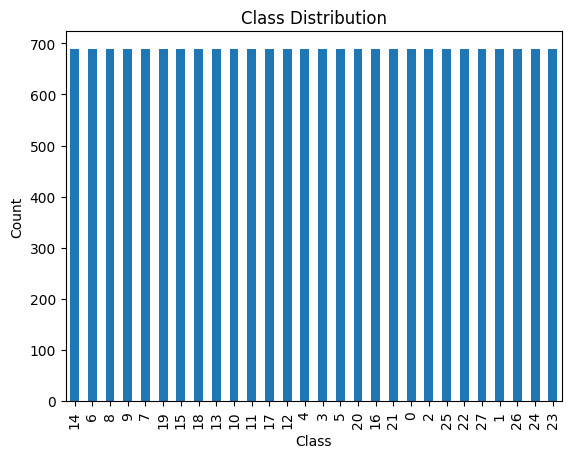

Dataset is balanced.
Class Distribution of:balancedData\Absenteeism_at_work.csv
 target
4     208
0     208
2     208
7     208
11    208
1     208
6     208
3     208
10    208
5     208
8     208
9     208
14    208
13    208
15    208
18    208
17    208
16    208
12    208
Name: count, dtype: int64


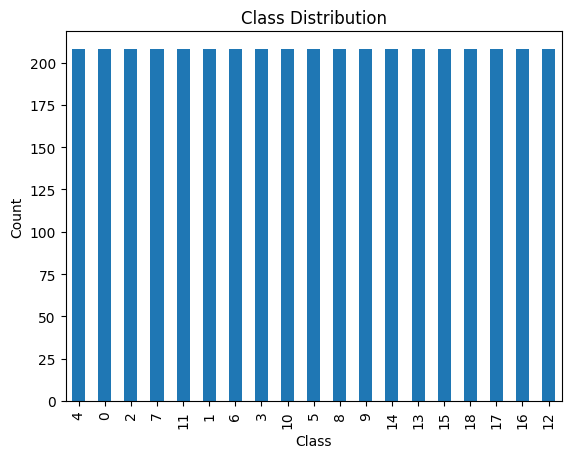

Dataset is balanced.
Class Distribution of:balancedData\Acoustic Features.csv
 Class
2    100
1    100
3    100
0    100
Name: count, dtype: int64


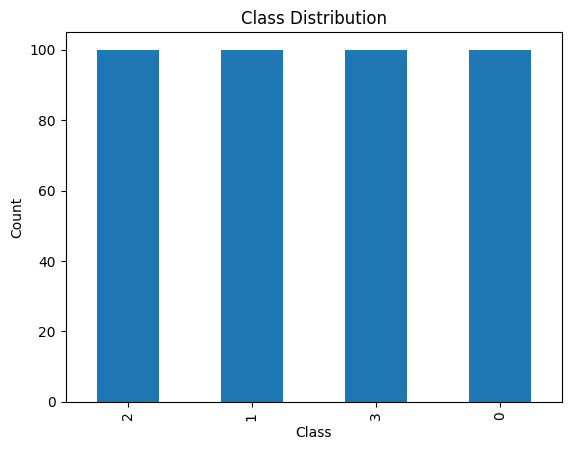

Dataset is balanced.
Class Distribution of:balancedData\acute-inflammation.csv
 decision: Nephritis of renal pelvis origin
0    70
1    50
Name: count, dtype: int64


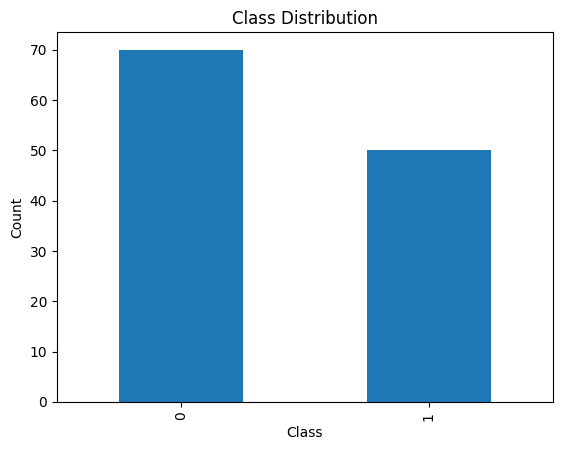

Dataset is balanced.
Class Distribution of:balancedData\Acute-urinary.csv
 decision: Nephritis of renal pelvis origin
0    70
1    50
Name: count, dtype: int64


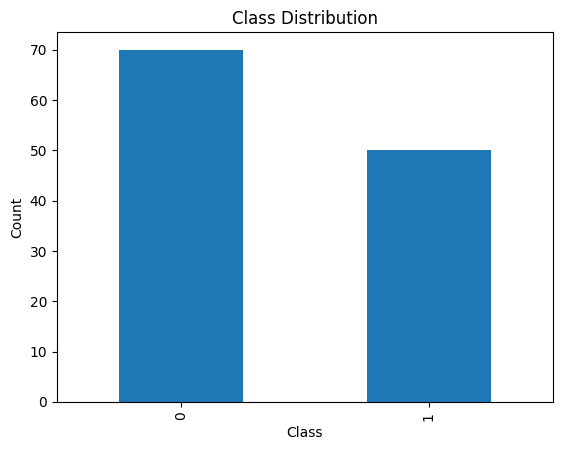

Dataset is balanced.
Class Distribution of:balancedData\Algerian_forest_fires_dataset_UPDATE.csv
 target
6    131
3    131
1    131
2    131
4    131
5    131
9    131
0    131
8    131
7    131
Name: count, dtype: int64


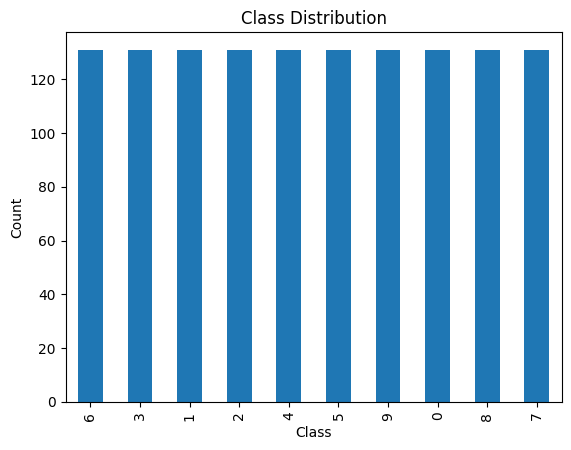

Dataset is balanced.
Class Distribution of:balancedData\Annealing.csv
 target
2    608
4    608
0    608
3    608
1    608
Name: count, dtype: int64


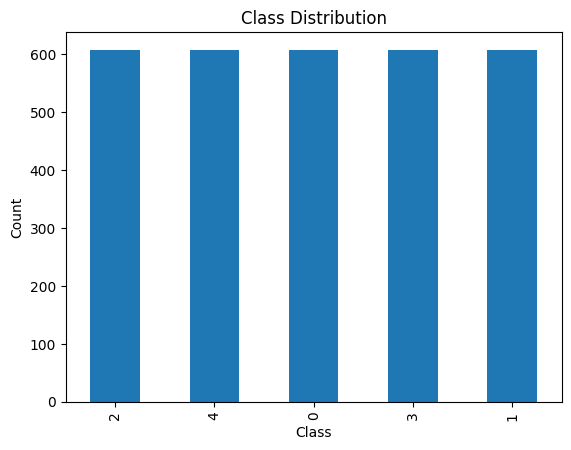

Dataset is balanced.
Class Distribution of:balancedData\auction.csv
 target
0    1781
1    1781
Name: count, dtype: int64


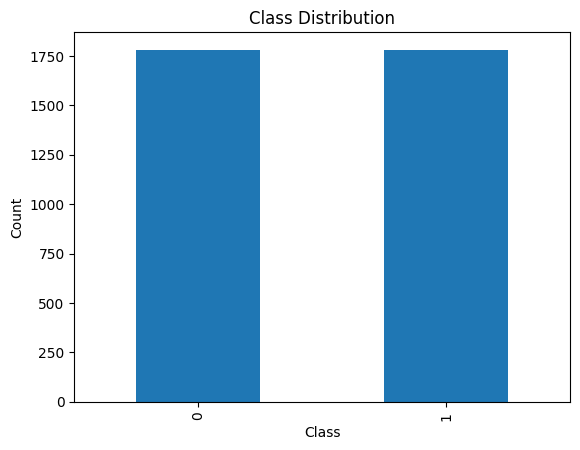

Dataset is balanced.
Class Distribution of:balancedData\audiology.csv
 target
7     48
10    48
11    48
2     48
18    48
6     48
3     48
0     48
15    48
8     48
23    48
9     48
1     48
5     48
14    48
17    48
19    48
22    48
21    48
4     48
12    48
13    48
16    48
20    48
Name: count, dtype: int64


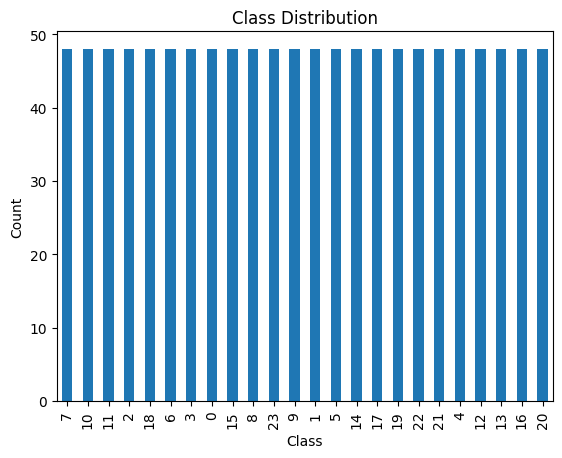

Dataset is balanced.
Class Distribution of:balancedData\austrCredit .csv
 class
0    383
1    307
Name: count, dtype: int64


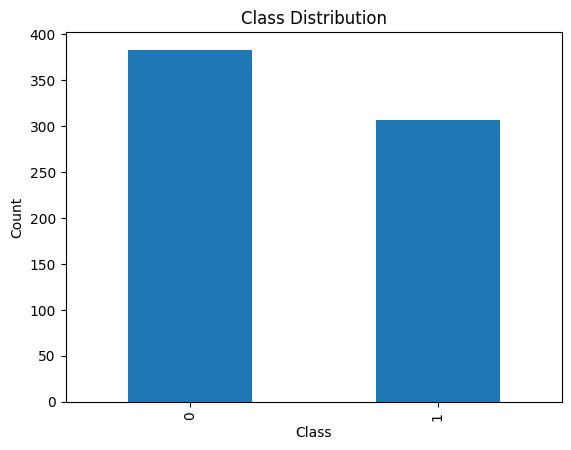

Dataset is balanced.
Class Distribution of:balancedData\austrlian statelog.csv
 target
0    383
1    307
Name: count, dtype: int64


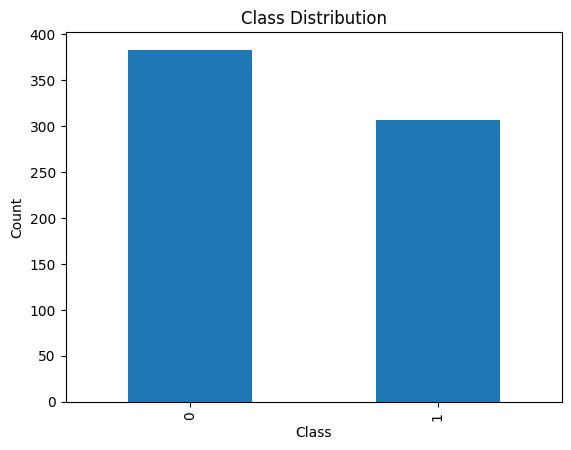

Dataset is balanced.
Class Distribution of:balancedData\austrlian2.csv
 target
0    383
1    307
Name: count, dtype: int64


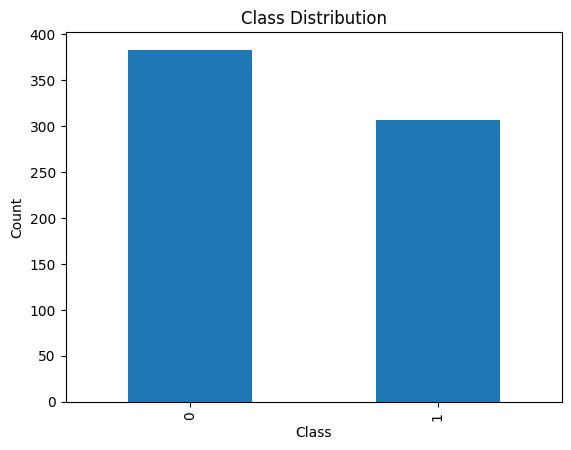

Dataset is balanced.
Class Distribution of:balancedData\Autism-Adult-Data.csv
 target
0    515
1    515
Name: count, dtype: int64


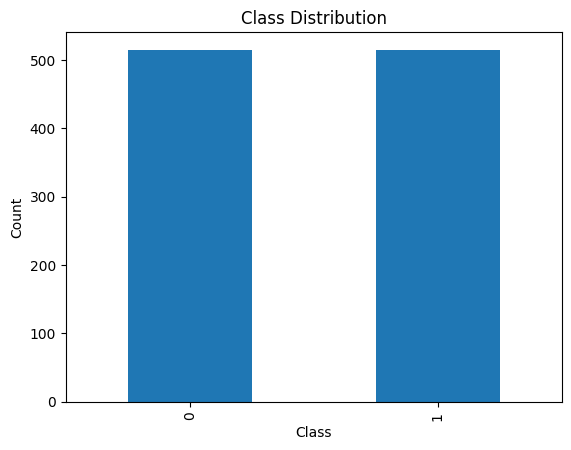

Dataset is balanced.
Class Distribution of:balancedData\balance-scaledata.csv
 target
0    288
2    288
1    288
Name: count, dtype: int64


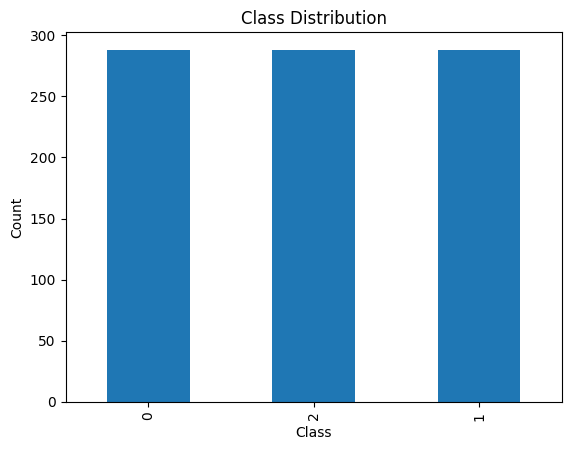

Dataset is balanced.
Class Distribution of:balancedData\ballons.csv
 inflated
0    12
1     8
Name: count, dtype: int64


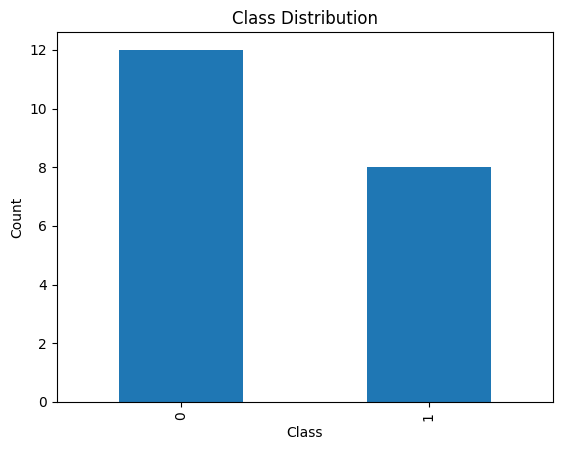

Dataset is balanced.
Class Distribution of:balancedData\BankNote_Authentication.csv
 class
0    762
1    610
Name: count, dtype: int64


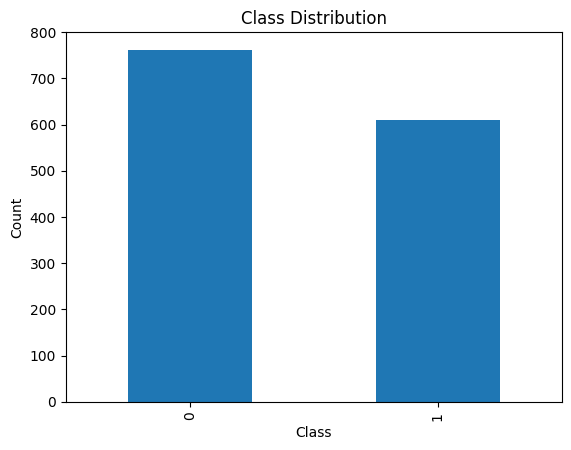

Dataset is balanced.
Class Distribution of:balancedData\bankruptcy.csv
 target
1    6599
0    6599
Name: count, dtype: int64


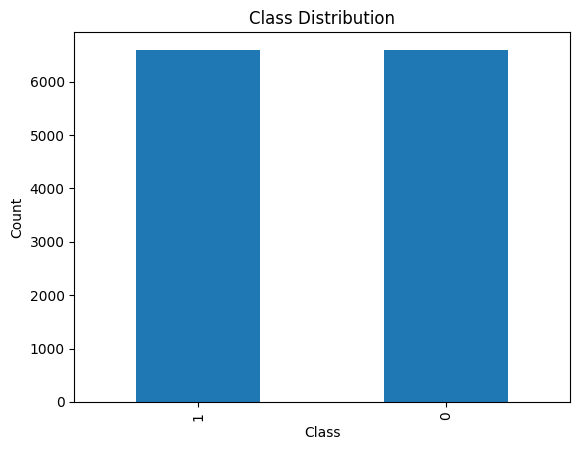

Dataset is balanced.
Class Distribution of:balancedData\braest-cancer wincosin.csv
 Diagnosis
0    357
1    212
Name: count, dtype: int64


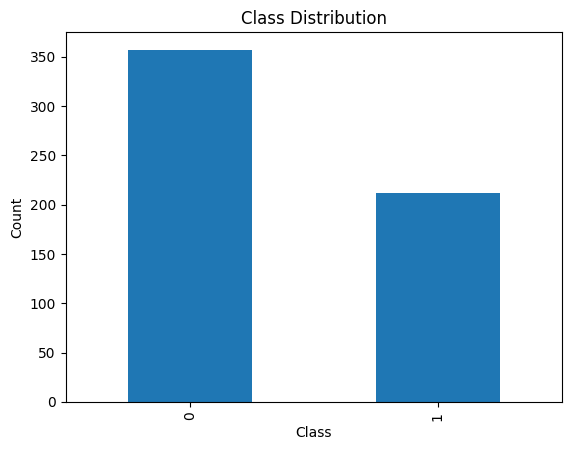

Dataset is balanced.
Class Distribution of:balancedData\breast_cancer.csv
 diagnosis
0    357
1    212
Name: count, dtype: int64


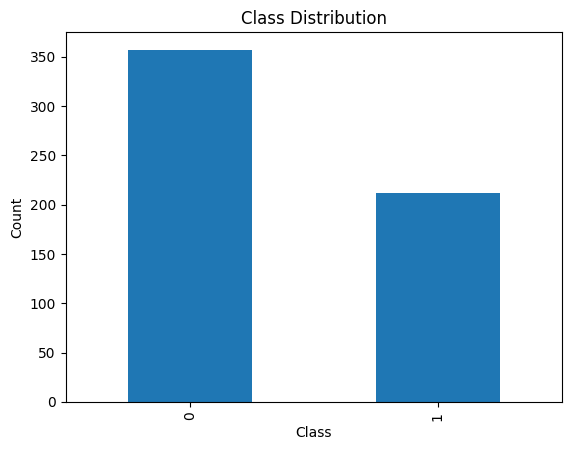

Dataset is balanced.
Class Distribution of:balancedData\bridges1.csv
 target
6    44
5    44
4    44
0    44
1    44
3    44
2    44
7    44
Name: count, dtype: int64


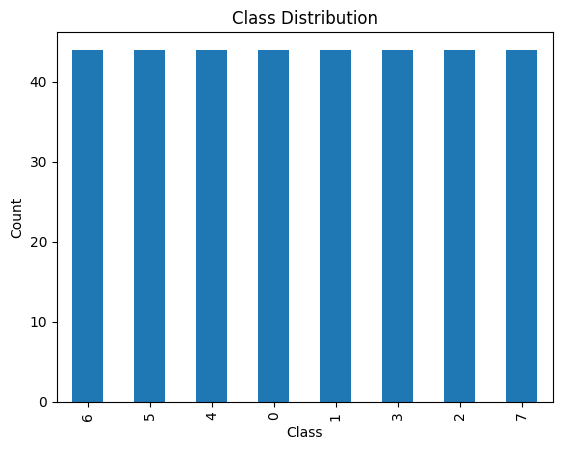

Dataset is balanced.
Class Distribution of:balancedData\bridges2.csv
 target
6    44
5    44
4    44
0    44
1    44
3    44
2    44
7    44
Name: count, dtype: int64


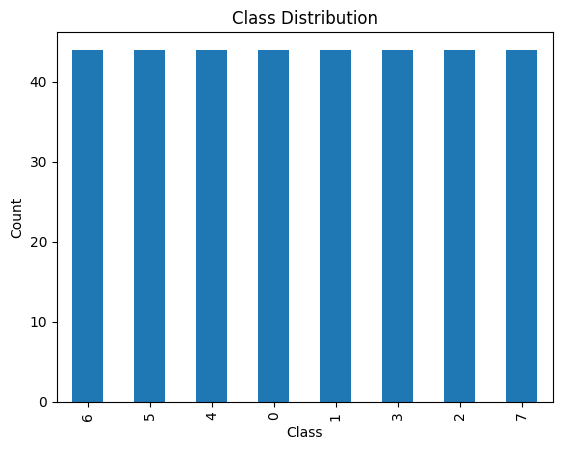

Dataset is balanced.
Class Distribution of:balancedData\car_evaluation.csv
 target
2    1209
0    1209
3    1209
1    1209
Name: count, dtype: int64


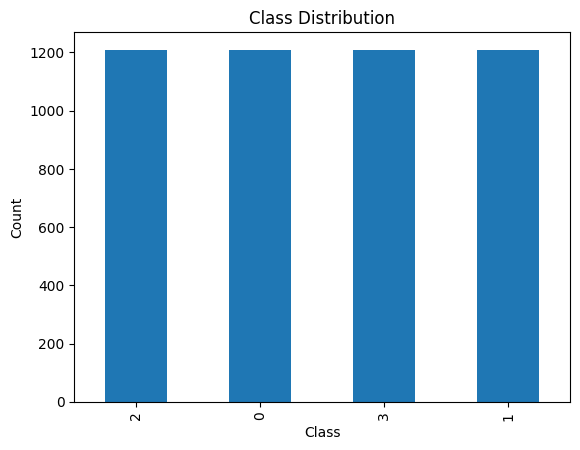

Dataset is balanced.
Class Distribution of:balancedData\chess.csv
 class
1    1669
0    1527
Name: count, dtype: int64


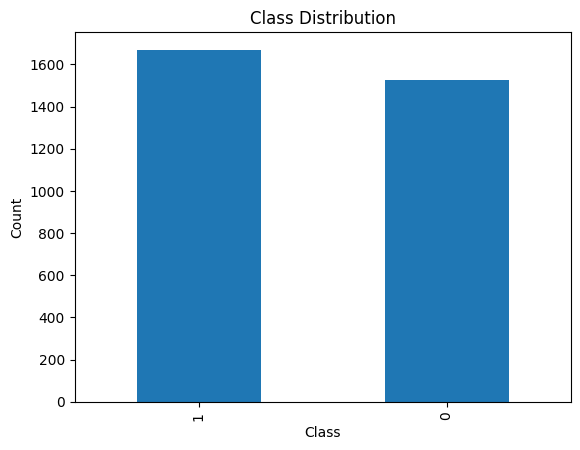

Dataset is balanced.
Class Distribution of:balancedData\cirrhosis.csv
 target
3    155
2    155
1    155
0    155
4    155
Name: count, dtype: int64


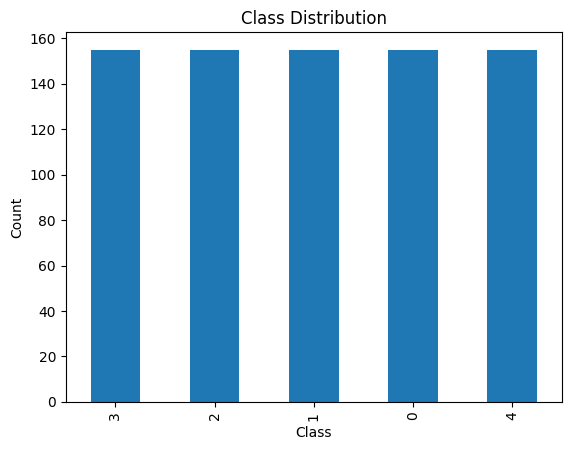

Dataset is balanced.
Class Distribution of:balancedData\cmc.csv
 contraceptive_method
0    629
2    511
1    333
Name: count, dtype: int64


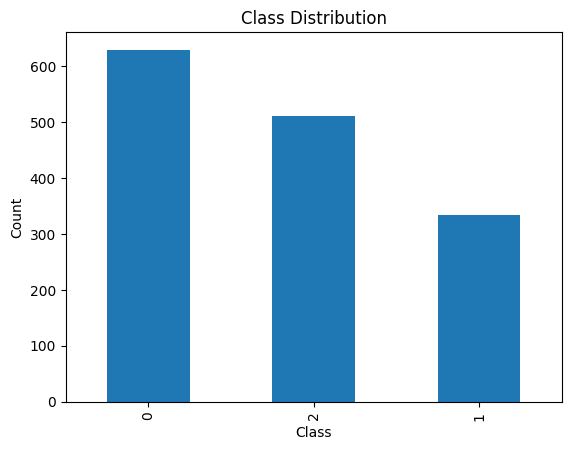

Dataset is balanced.
Class Distribution of:balancedData\connect4.csv
 target
2    44473
0    44473
1    44473
Name: count, dtype: int64


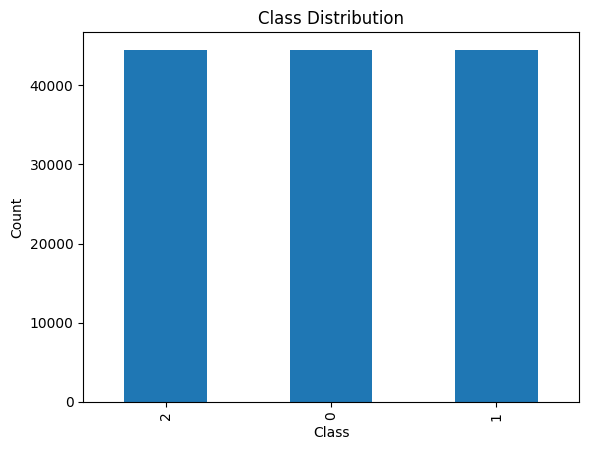

Dataset is balanced.
Class Distribution of:balancedData\csv_result-caesarian.csv
 Caesarian(class)
1    46
0    34
Name: count, dtype: int64


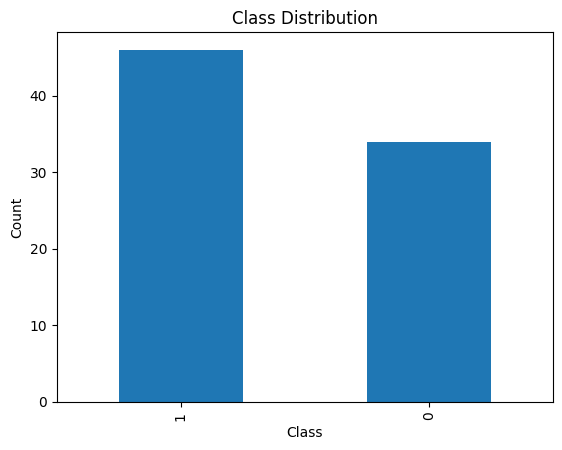

Dataset is balanced.
Class Distribution of:balancedData\csv_result-climate.csv
 target
0    494
1    494
Name: count, dtype: int64


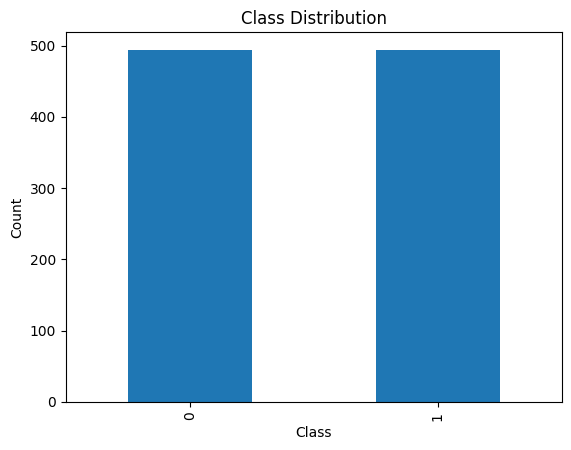

Dataset is balanced.
Class Distribution of:balancedData\csv_result-column_2C_weka.csv
 target
0    210
1    210
Name: count, dtype: int64


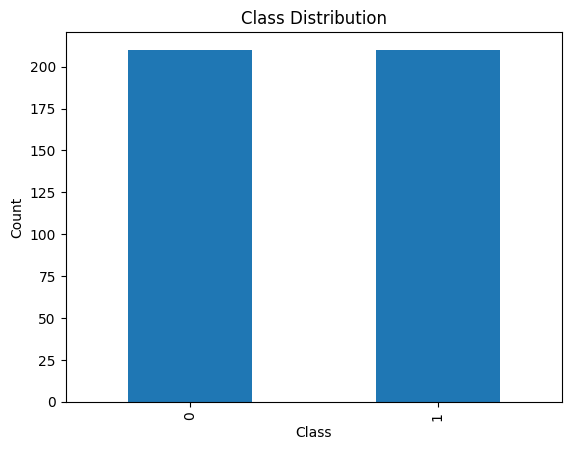

Dataset is balanced.
Class Distribution of:balancedData\csv_result-column_3C_weka.csv
 target
0    150
2    150
1    150
Name: count, dtype: int64


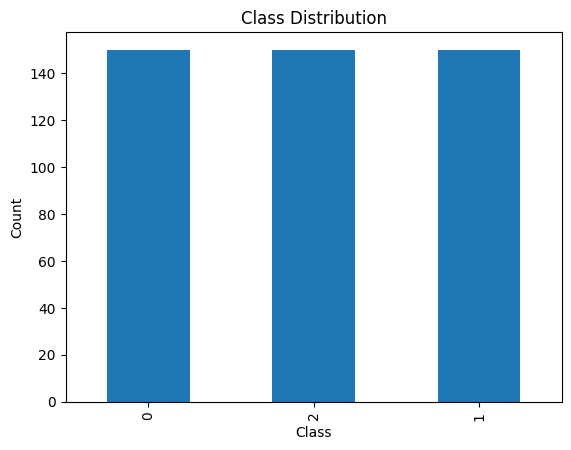

Dataset is balanced.
Class Distribution of:balancedData\csv_result-MagicTelescope.csv
 class:
0    12332
1     6688
Name: count, dtype: int64


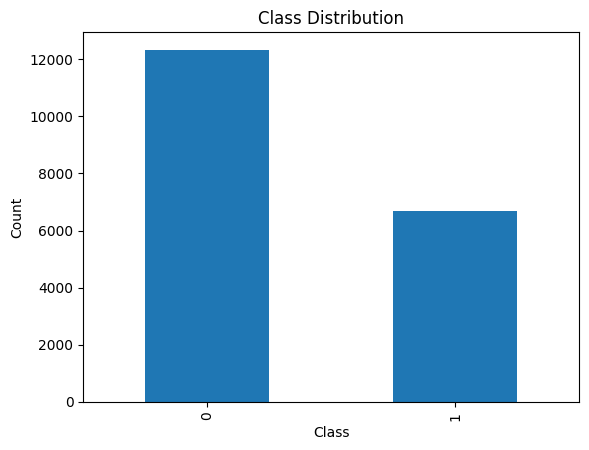

Dataset is balanced.
Class Distribution of:balancedData\csv_result-phpV5QYya.csv
 Result
1    6157
0    4898
Name: count, dtype: int64


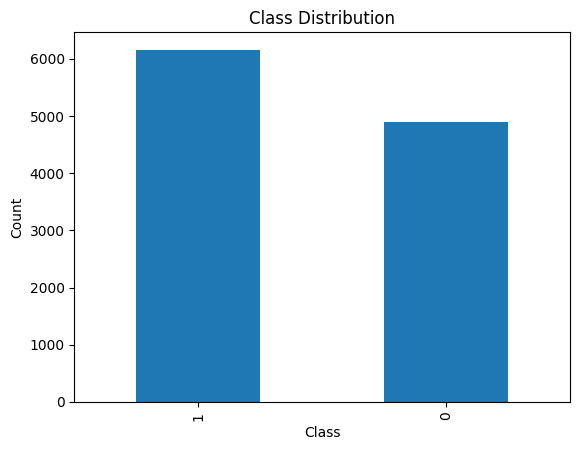

Dataset is balanced.
Class Distribution of:balancedData\csv_result-ThoraricSurgery.csv
 target
0    400
1    400
Name: count, dtype: int64


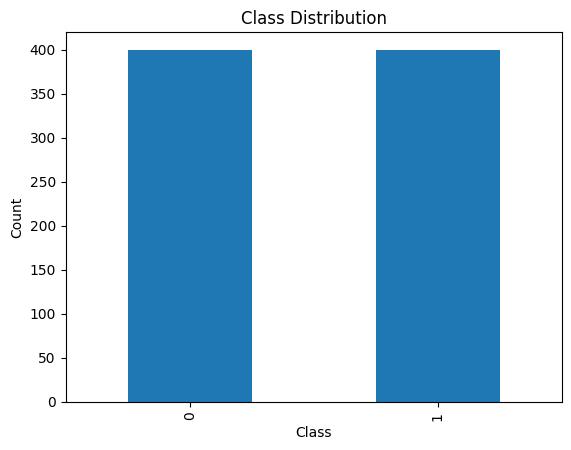

Dataset is balanced.
Class Distribution of:balancedData\Customer Churn.csv
 target
0    2655
1    2655
Name: count, dtype: int64


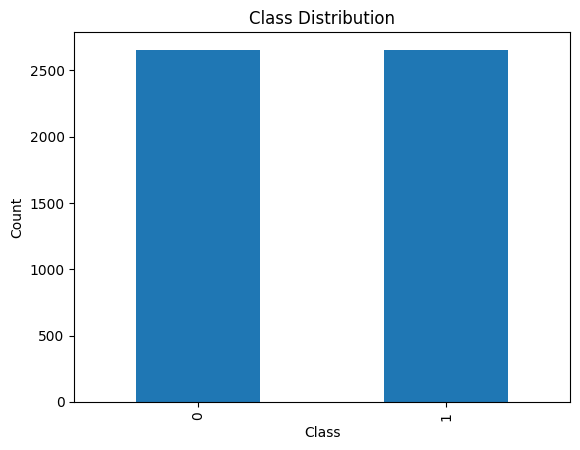

Dataset is balanced.
Class Distribution of:balancedData\cylinder_bands.csv
 target
0    312
1    312
2    312
Name: count, dtype: int64


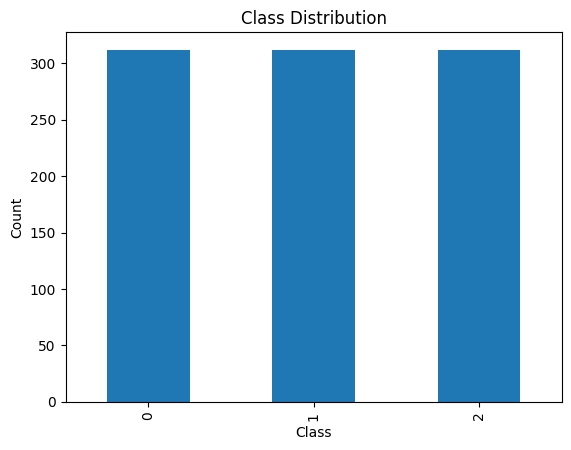

Dataset is balanced.
Class Distribution of:balancedData\dataR2.csv
 Classification
1    64
0    52
Name: count, dtype: int64


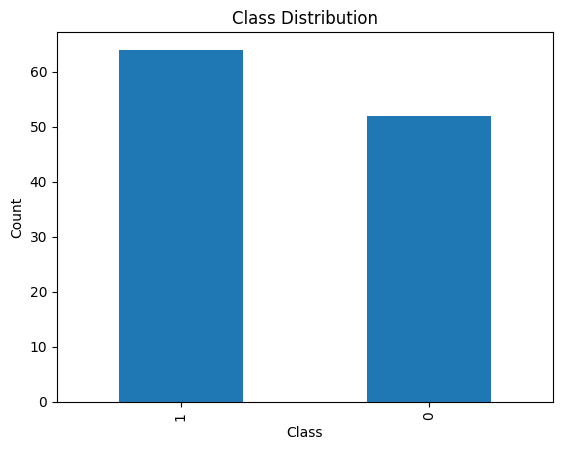

Dataset is balanced.
Class Distribution of:balancedData\dermatology.csv
 target
1    112
0    112
2    112
4    112
3    112
5    112
Name: count, dtype: int64


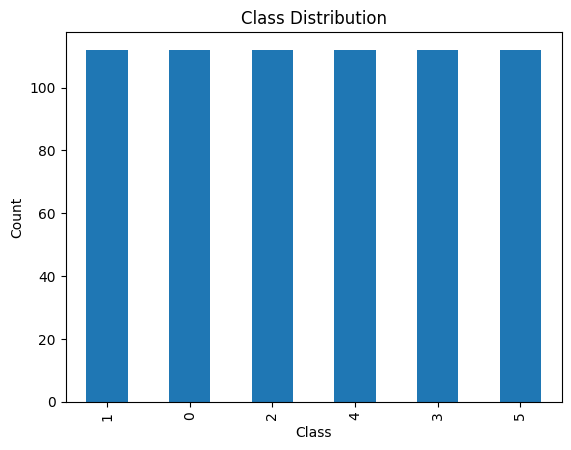

Dataset is balanced.
Class Distribution of:balancedData\diabetes.csv
 Outcome
0    500
1    268
Name: count, dtype: int64


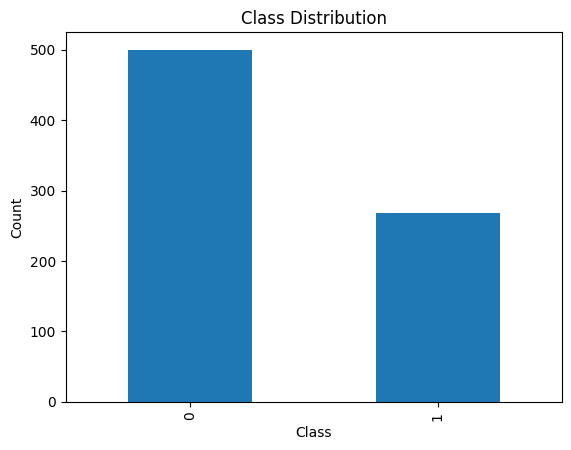

Dataset is balanced.
Class Distribution of:balancedData\diabetes_data_upload.csv
 class
1    320
0    200
Name: count, dtype: int64


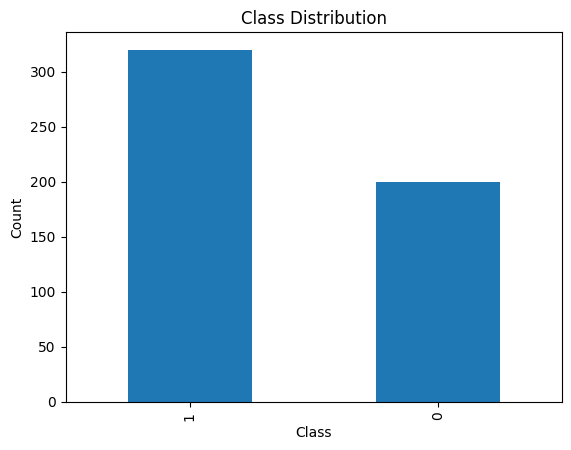

Dataset is balanced.
Class Distribution of:balancedData\dressDataSet.csv
 Recommendation
0    290
1    210
Name: count, dtype: int64


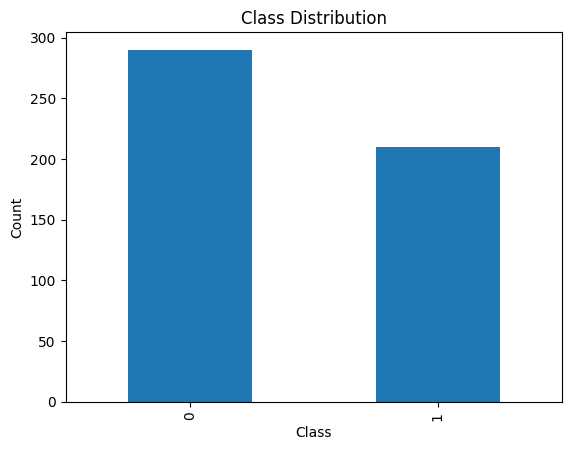

Dataset is balanced.
Class Distribution of:balancedData\Dry_Bean_Dataset.csv
 target
5    3546
0    3546
1    3546
2    3546
4    3546
6    3546
3    3546
Name: count, dtype: int64


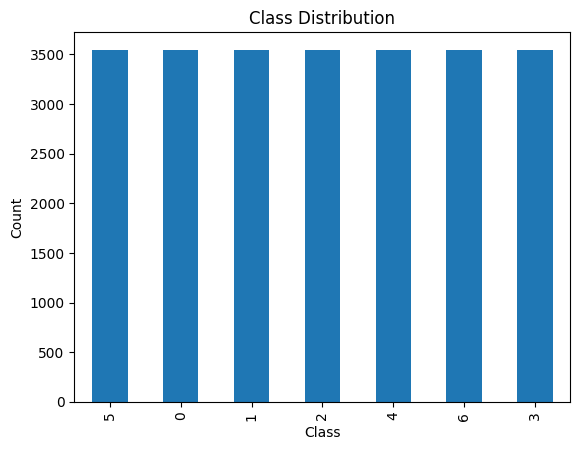

Dataset is balanced.
Class Distribution of:balancedData\ecoli.csv
 target
0    143
1    143
3    143
2    143
4    143
5    143
6    143
7    143
Name: count, dtype: int64


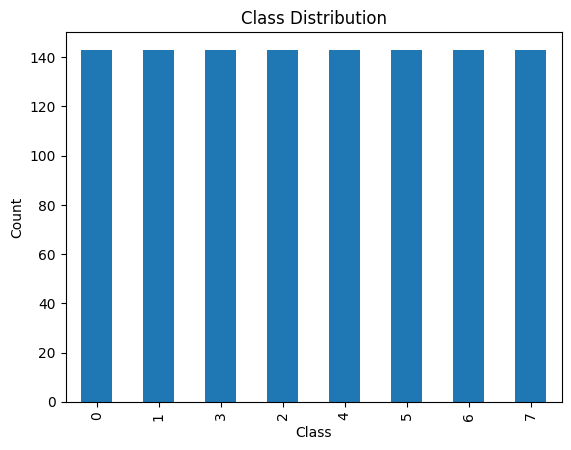

Dataset is balanced.
Class Distribution of:balancedData\EEG_Eye_State_Classification.csv
 eyeDetectionclass
0    8257
1    6723
Name: count, dtype: int64


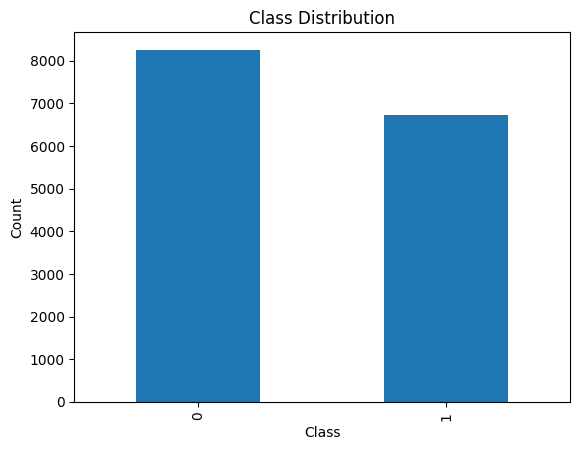

Dataset is balanced.
Class Distribution of:balancedData\electrical.csv
 class
1    6380
0    3620
Name: count, dtype: int64


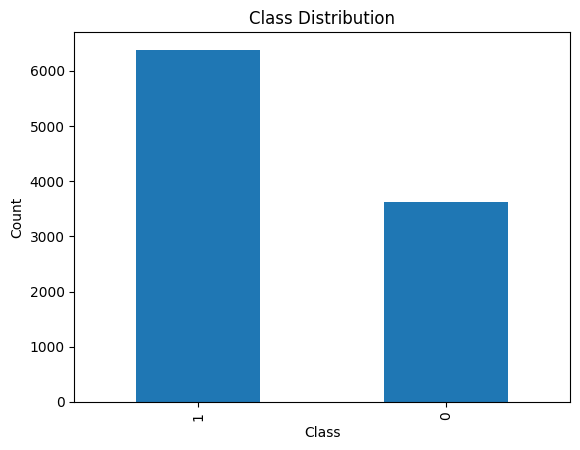

Dataset is balanced.
Class Distribution of:balancedData\electricity.csv
 class
0    26075
1    19237
Name: count, dtype: int64


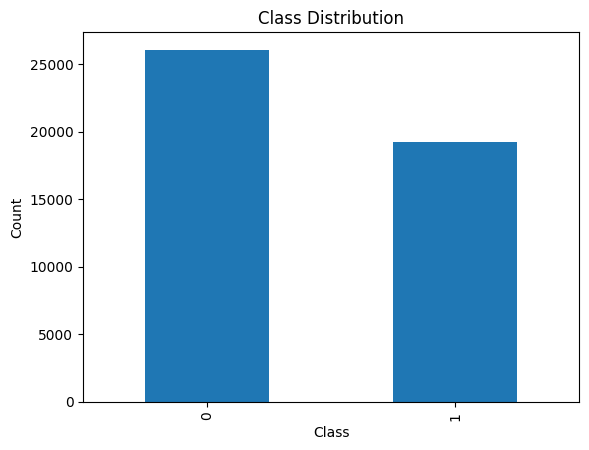

Dataset is balanced.
Class Distribution of:balancedData\faults.csv
 class
0    1268
1     673
Name: count, dtype: int64


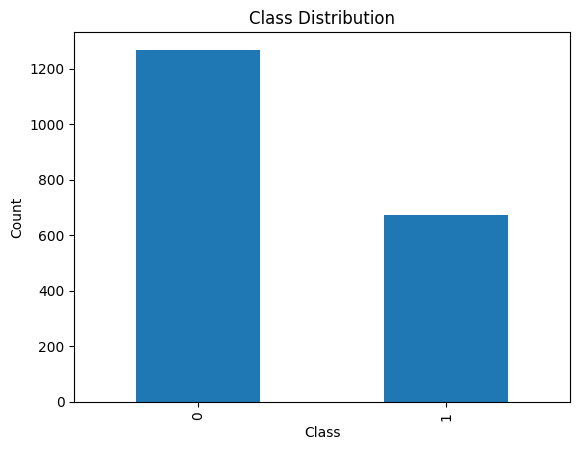

Dataset is balanced.
Class Distribution of:balancedData\fertility.csv
 target
0    88
1    88
Name: count, dtype: int64


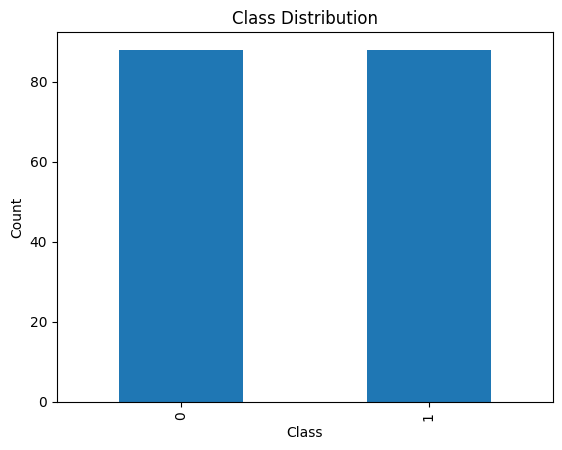

Dataset is balanced.
Class Distribution of:balancedData\flags.csv
 target
4    52
2    52
3    52
5    52
0    52
1    52
Name: count, dtype: int64


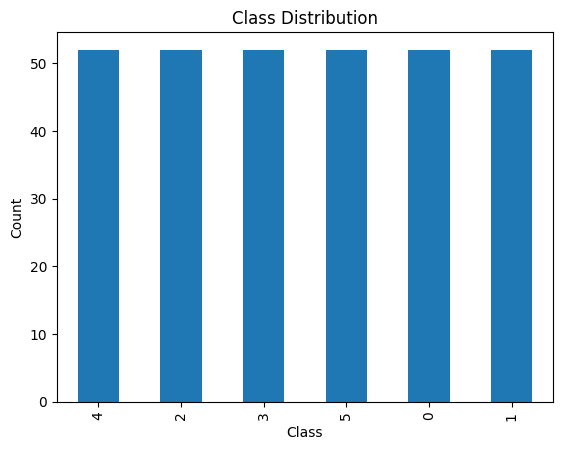

Dataset is balanced.
Class Distribution of:balancedData\forestType.csv
 class
3    59
0    54
1    48
2    37
Name: count, dtype: int64


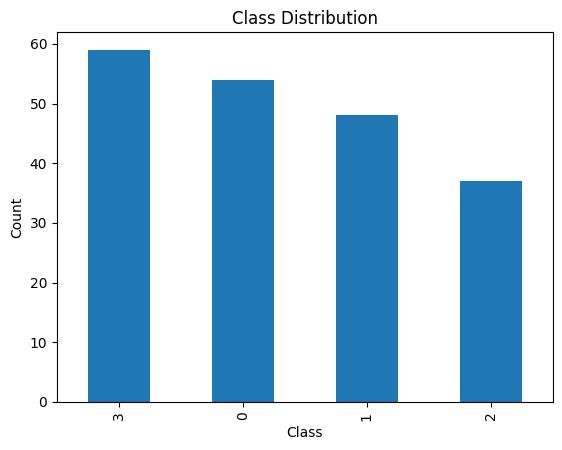

Dataset is balanced.
Class Distribution of:balancedData\German Credit Data.csv
 target
0    700
1    700
Name: count, dtype: int64


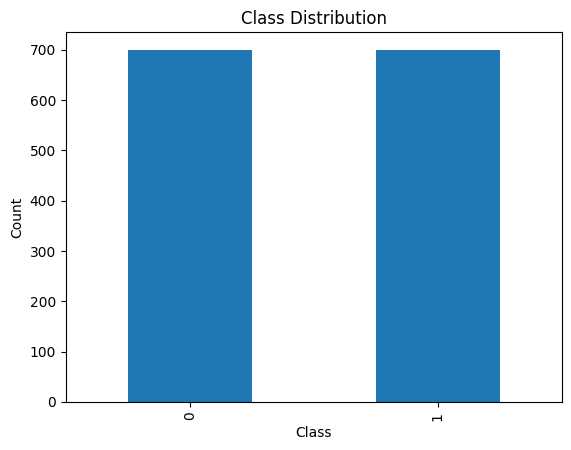

Dataset is balanced.
Class Distribution of:balancedData\glass.csv
 target
0    76
1    76
2    76
3    76
4    76
5    76
Name: count, dtype: int64


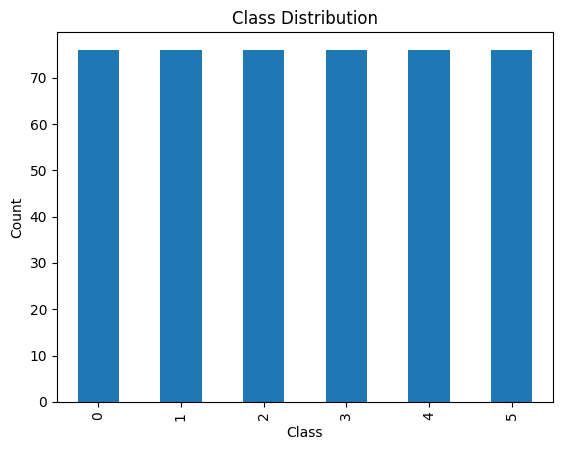

Dataset is balanced.
Class Distribution of:balancedData\haberman.csv
 target
0    225
1    225
Name: count, dtype: int64


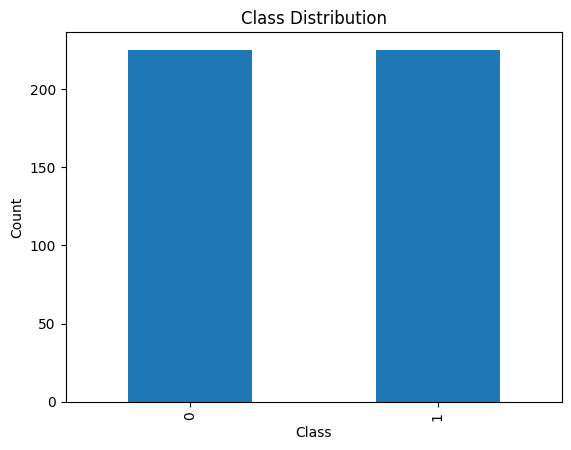

Dataset is balanced.
Class Distribution of:balancedData\hapetitis.csv
 target
1    123
0    123
Name: count, dtype: int64


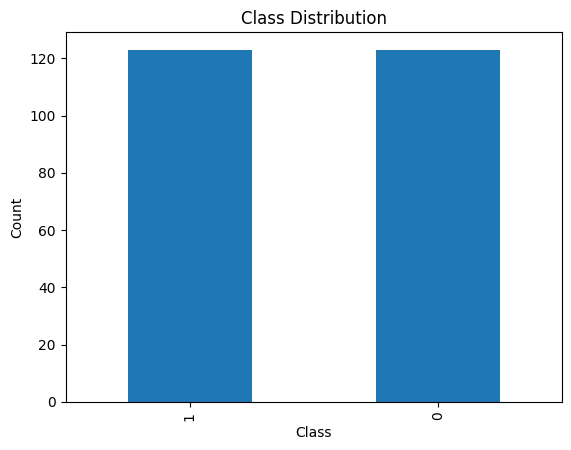

Dataset is balanced.
Class Distribution of:balancedData\hayes-roth.csv
 class
0    51
1    51
2    30
Name: count, dtype: int64


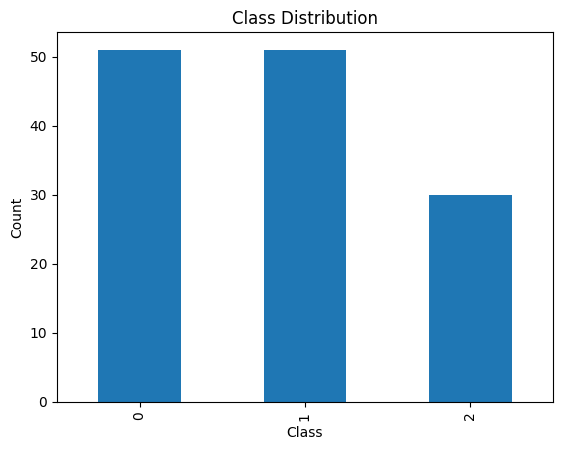

Dataset is balanced.
Class Distribution of:balancedData\hcvdat0.csv
 target
1    533
0    533
4    533
3    533
2    533
Name: count, dtype: int64


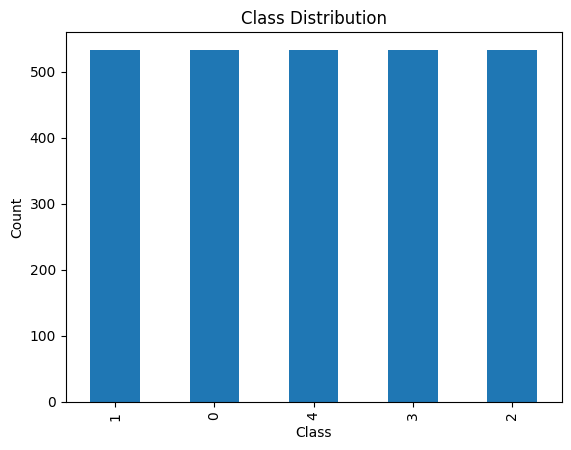

Dataset is balanced.
Class Distribution of:balancedData\heart.csv
 target
1    526
0    499
Name: count, dtype: int64


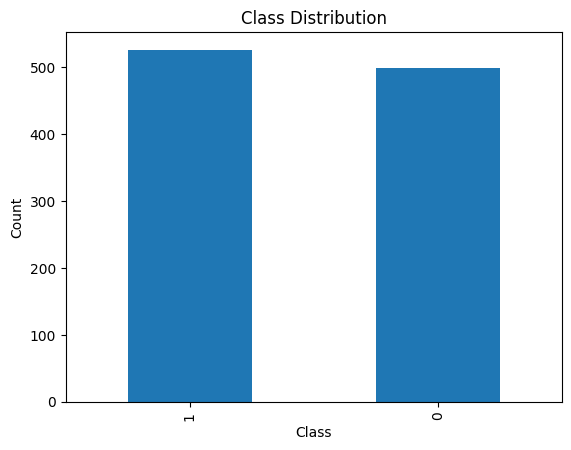

Dataset is balanced.
Class Distribution of:balancedData\heart_failure_clinical_records_dataset.csv
 target
1    203
0    203
Name: count, dtype: int64


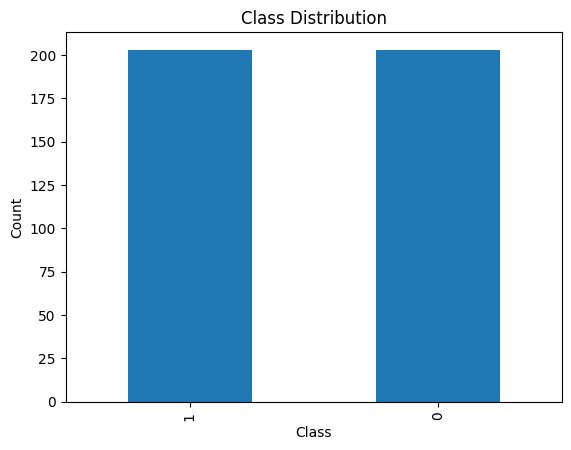

Dataset is balanced.
Class Distribution of:balancedData\horse-ecolic surgical.csv
 surgical_lesion
0    191
1    109
Name: count, dtype: int64


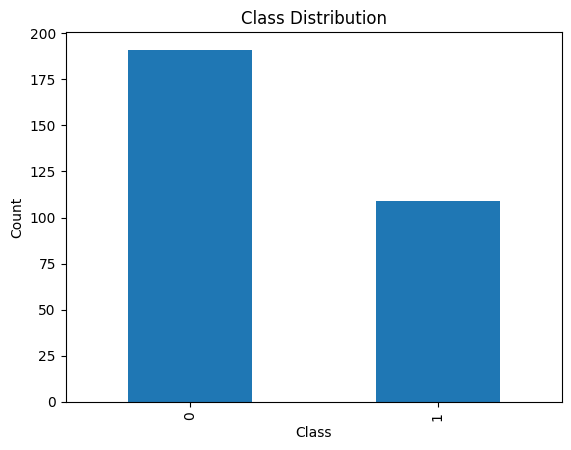

Dataset is balanced.
Class Distribution of:balancedData\house_voting.csv
 Class Name
0    267
1    168
Name: count, dtype: int64


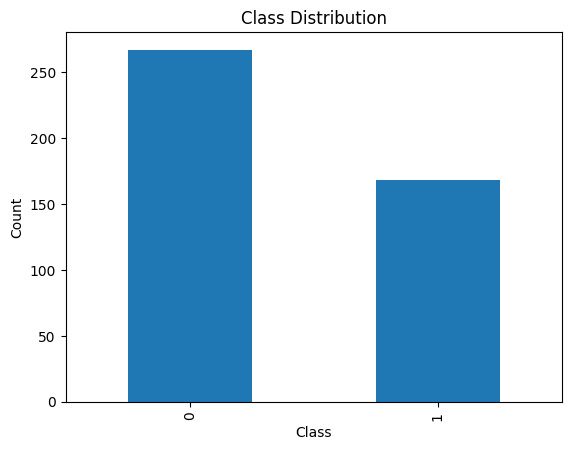

Dataset is balanced.
Class Distribution of:balancedData\imageSegmentation.csv
 class
0    30
5    30
2    30
1    30
6    30
4    30
3    30
Name: count, dtype: int64


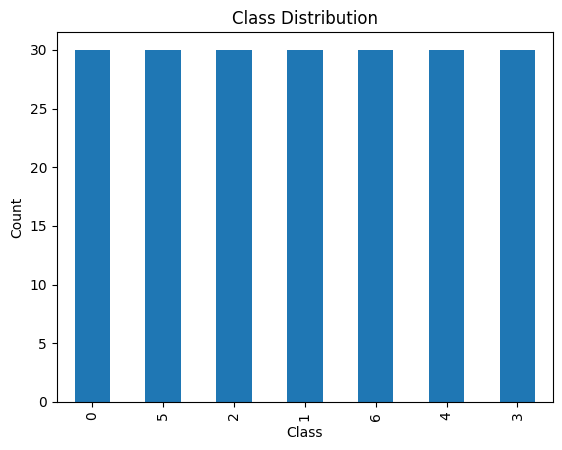

Dataset is balanced.
Class Distribution of:balancedData\Indian Liver Patient Dataset (ILPD).csv
 target
0    416
1    416
Name: count, dtype: int64


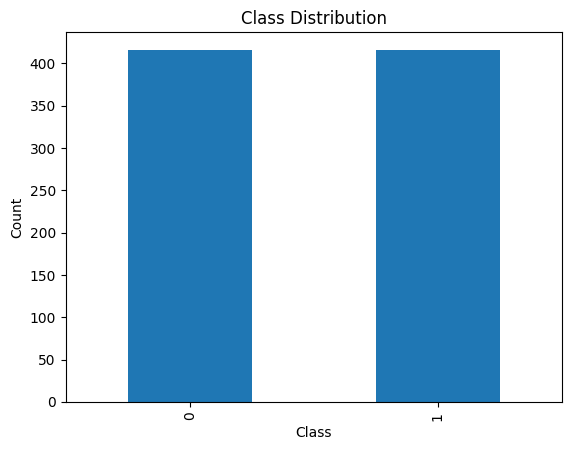

Dataset is balanced.
Class Distribution of:balancedData\indian liver.csv
 target
0    416
1    416
Name: count, dtype: int64


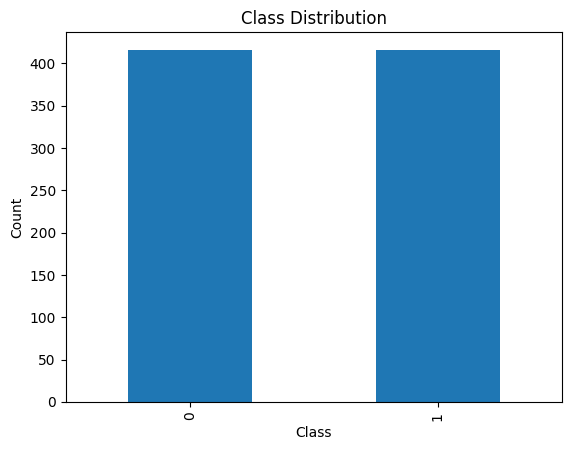

Dataset is balanced.
Class Distribution of:balancedData\indian_liver_patient.csv
 target
0    416
1    416
Name: count, dtype: int64


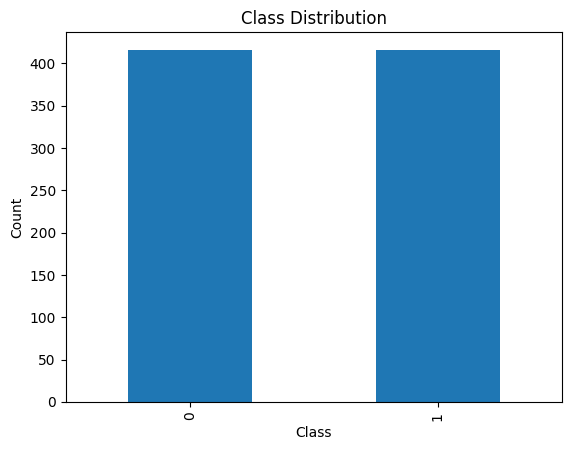

Dataset is balanced.
Class Distribution of:balancedData\ionospere.csv
 target
0    224
1    224
2    224
Name: count, dtype: int64


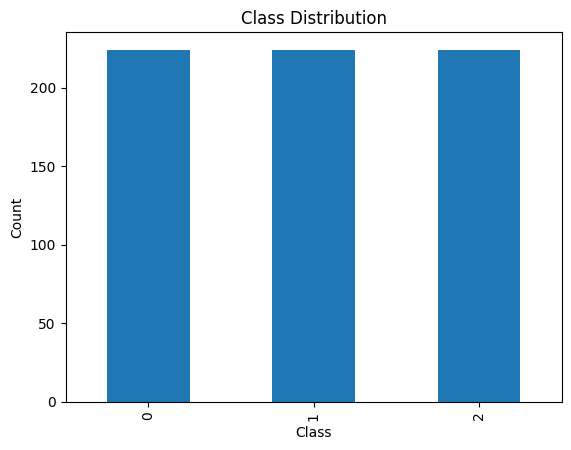

Dataset is balanced.
Class Distribution of:balancedData\Iris.csv
 Species
0    50
1    50
2    50
Name: count, dtype: int64


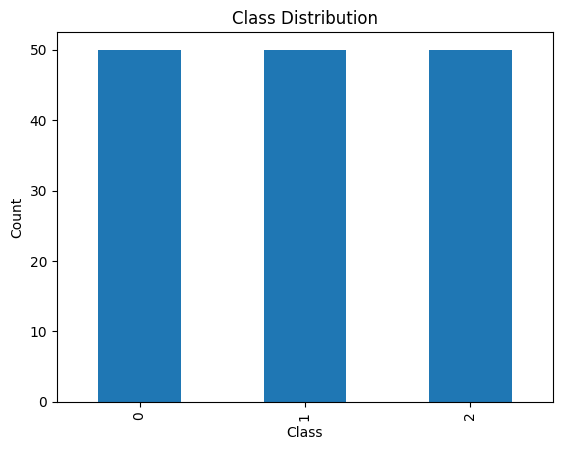

Dataset is balanced.
Class Distribution of:balancedData\iymphography.csv
 target
2    81
1    81
3    81
0    81
Name: count, dtype: int64


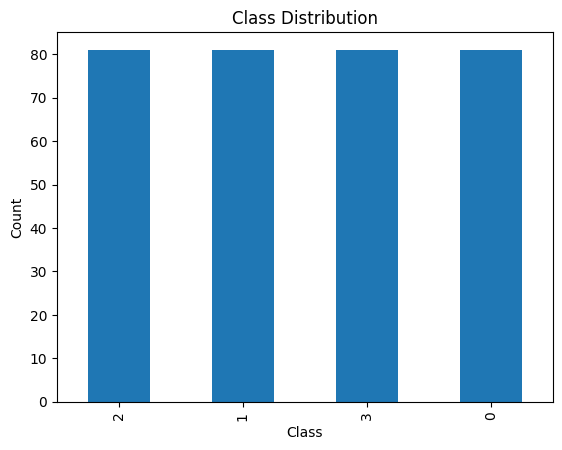

Dataset is balanced.
Class Distribution of:balancedData\lenses.csv
 target
2    15
1    15
0    15
Name: count, dtype: int64


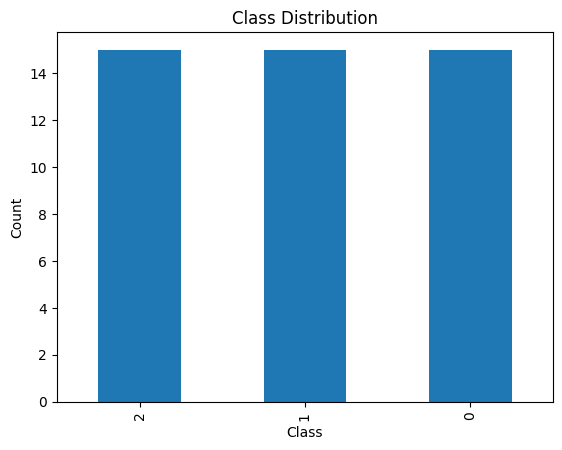

Dataset is balanced.
Class Distribution of:balancedData\librasMove.csv
 class
0     24
1     24
2     24
3     24
4     24
5     24
6     24
7     24
8     24
9     24
10    24
11    24
12    24
13    24
14    24
Name: count, dtype: int64


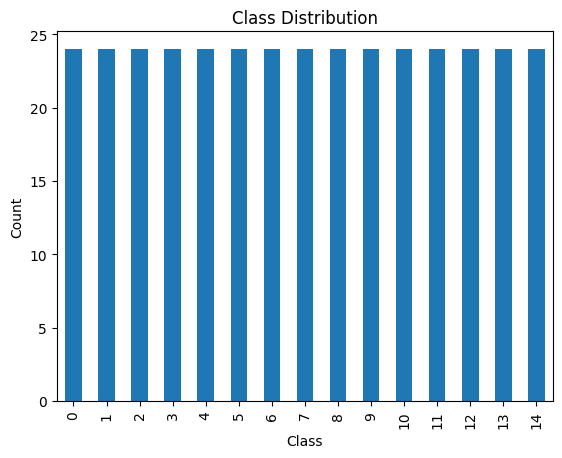

Dataset is balanced.
Class Distribution of:balancedData\lunCancer.csv
 target
0    13
1    13
2    13
3    13
Name: count, dtype: int64


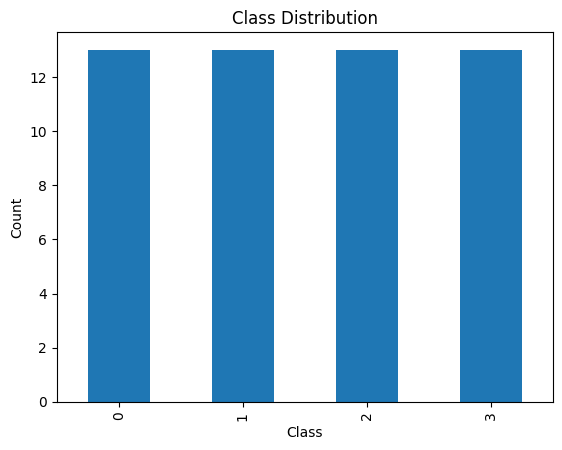

Dataset is balanced.
Class Distribution of:balancedData\mammographic.csv
 class
0    516
1    445
Name: count, dtype: int64


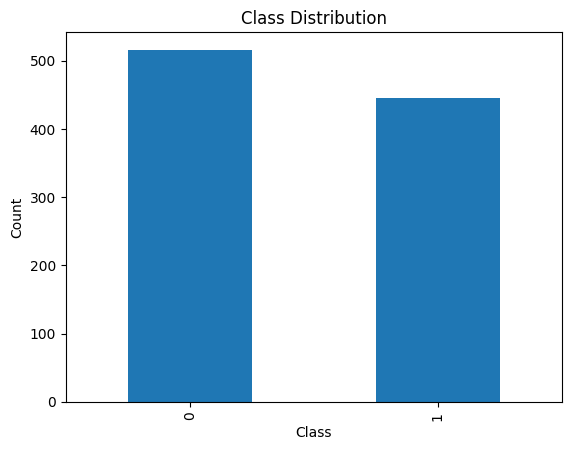

Dataset is balanced.
Class Distribution of:balancedData\meta-data.csv
 class
0     22
1     22
2     22
3     22
4     22
5     22
6     22
7     22
8     22
9     22
10    22
11    22
12    22
13    22
14    22
15    22
16    22
17    22
18    22
19    22
20    22
21    22
22    22
23    22
Name: count, dtype: int64


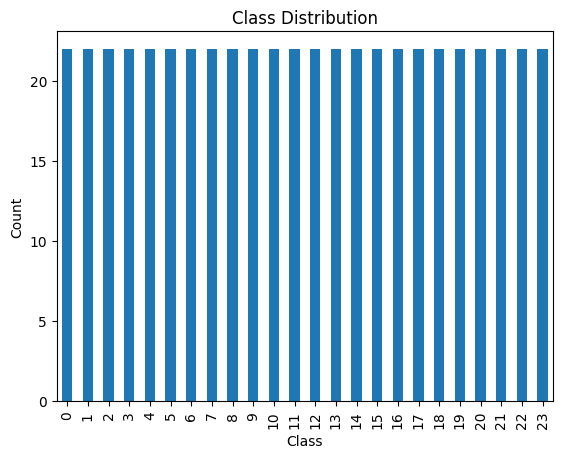

Dataset is balanced.
Class Distribution of:balancedData\miceproteinNuclear.csv
 class
0    150
2    150
1    135
3    135
4    135
6    135
7    135
5    105
Name: count, dtype: int64


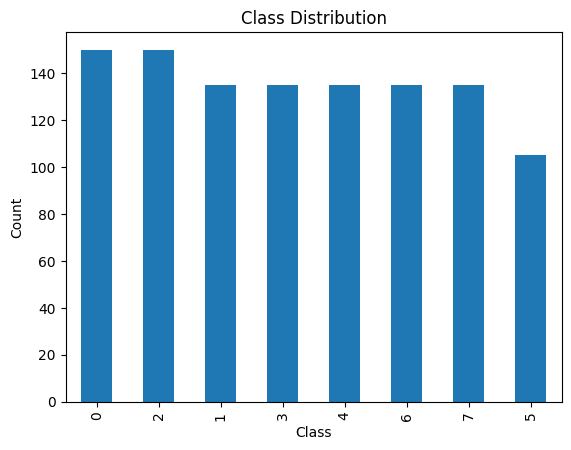

Dataset is balanced.
Class Distribution of:balancedData\molecular.csv
 target
0    1655
1    1655
2    1655
Name: count, dtype: int64


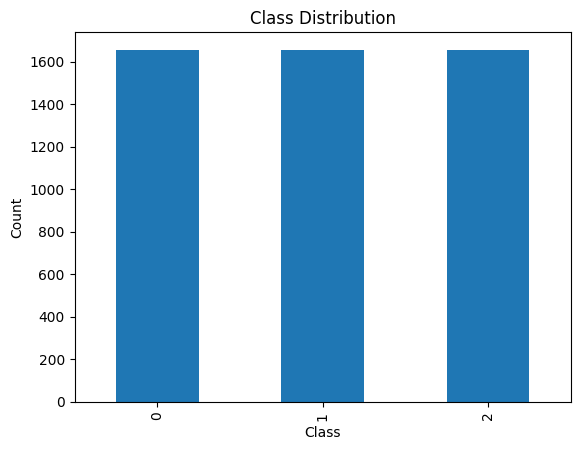

Dataset is balanced.
Class Distribution of:balancedData\monksTest1.csv
 class
1    216
0    216
Name: count, dtype: int64


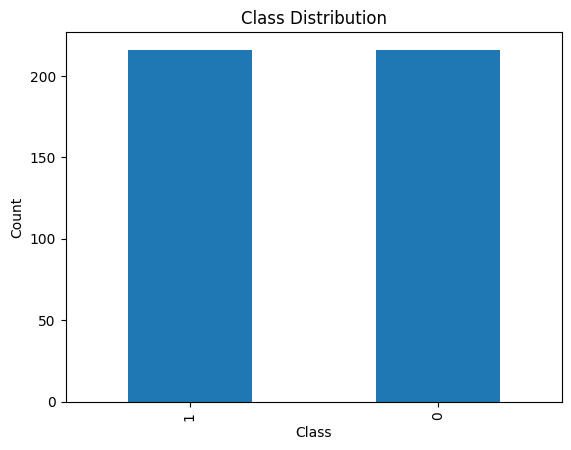

Dataset is balanced.
Class Distribution of:balancedData\monksTest2.csv
 target
0    290
1    290
Name: count, dtype: int64


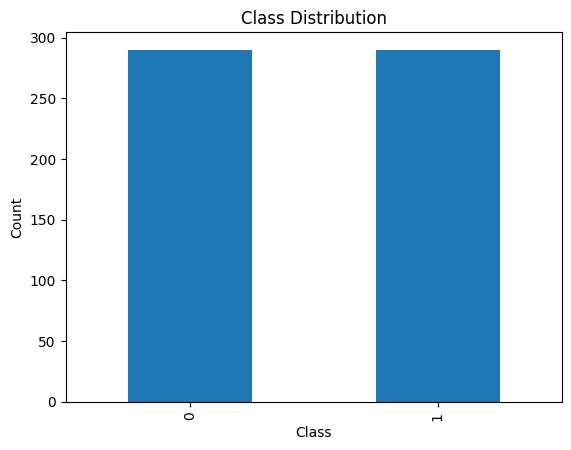

Dataset is balanced.
Class Distribution of:balancedData\monksTrain1.csv
 class
1    62
0    62
Name: count, dtype: int64


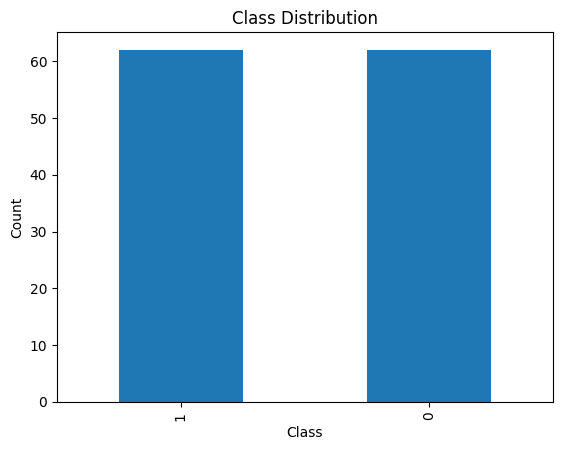

Dataset is balanced.
Class Distribution of:balancedData\Movie_classification.csv
 Start_Tech_Oscarclass
1    276
0    230
Name: count, dtype: int64


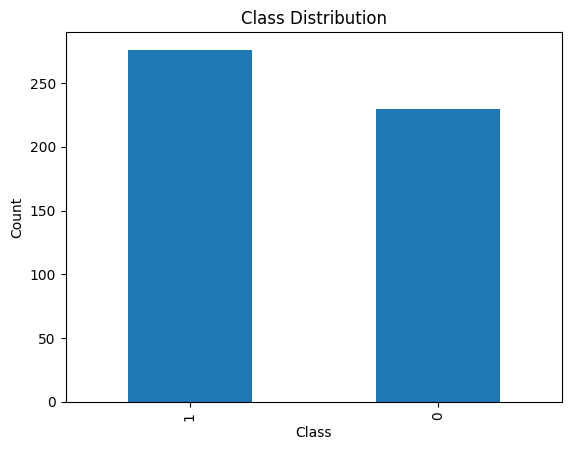

Dataset is balanced.
Class Distribution of:balancedData\mushroom.csv
 class
0    4208
1    3916
Name: count, dtype: int64


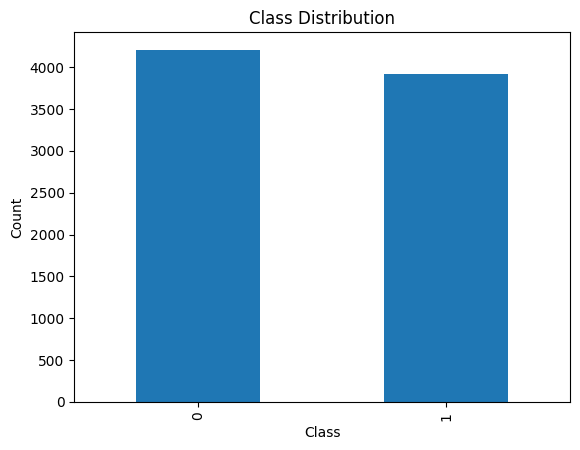

Dataset is balanced.
Class Distribution of:balancedData\non-verbal tourist data.csv
 target
0    36
1    36
2    36
3    36
4    36
5    36
Name: count, dtype: int64


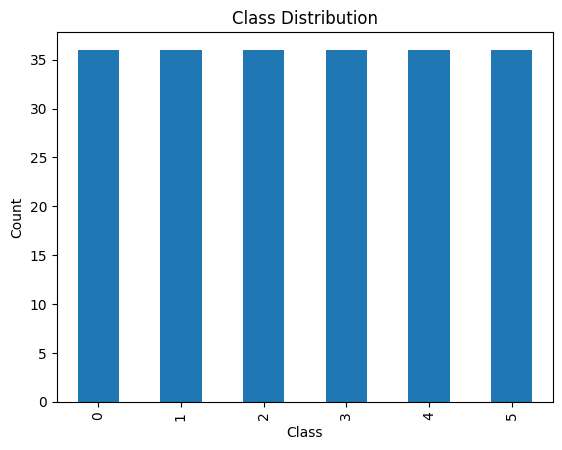

Dataset is balanced.
Class Distribution of:balancedData\NPHA-doctor-visits.csv
 target
2    372
1    372
0    372
Name: count, dtype: int64


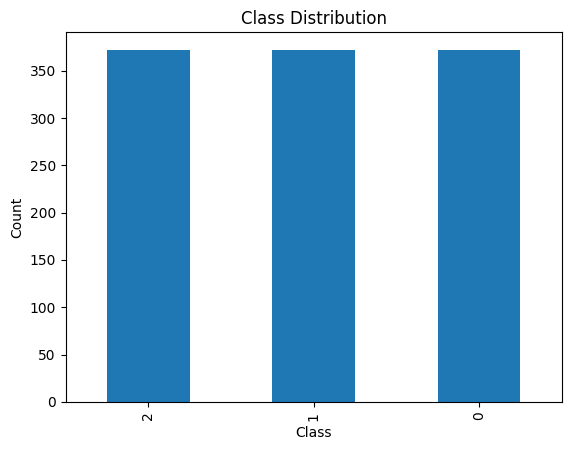

Dataset is balanced.
Class Distribution of:balancedData\ObesityDataSet_raw_and_data_sinthetic.csv
 NObeyesdad
2    351
4    324
3    297
5    290
6    290
1    287
0    272
Name: count, dtype: int64


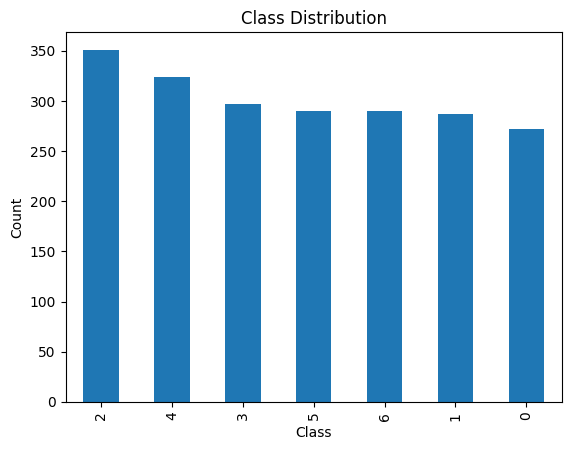

Dataset is balanced.
Class Distribution of:balancedData\ozonedet.csv
 target
0    2374
1    2374
Name: count, dtype: int64


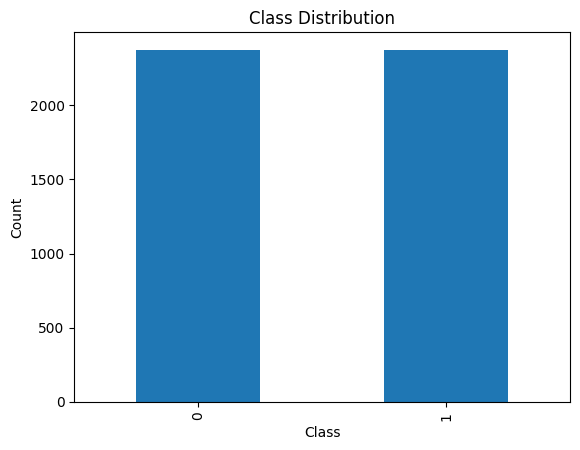

Dataset is balanced.
Class Distribution of:balancedData\pageBlock.csv
 target
0    4913
1    4913
3    4913
4    4913
2    4913
Name: count, dtype: int64


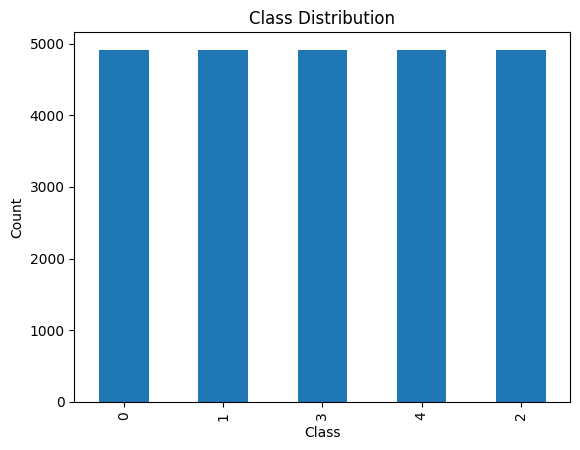

Dataset is balanced.
Class Distribution of:balancedData\parkinsons.csv
 target
1    147
0    147
Name: count, dtype: int64


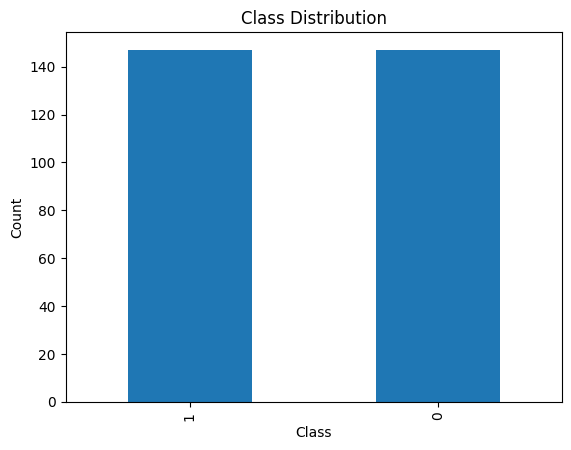

Dataset is balanced.
Class Distribution of:balancedData\penReco.csv
 class
2    780
4    780
0    780
1    779
7    778
6    720
5    720
8    719
9    719
3    719
Name: count, dtype: int64


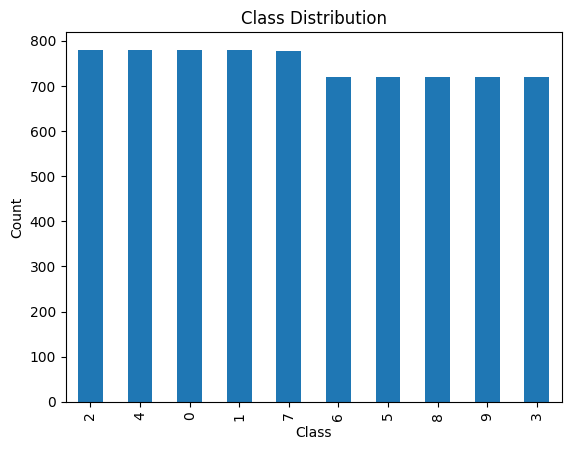

Dataset is balanced.
Class Distribution of:balancedData\phone.csv
 price_range(class)
1    500
2    500
3    500
0    500
Name: count, dtype: int64


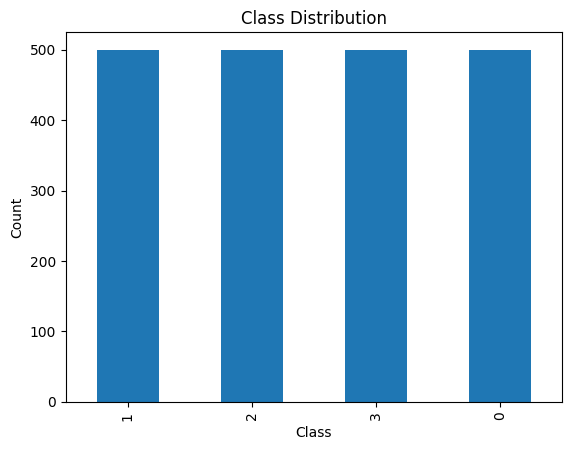

Dataset is balanced.
Class Distribution of:balancedData\planningRelax.csv
 target
0    130
1    130
Name: count, dtype: int64


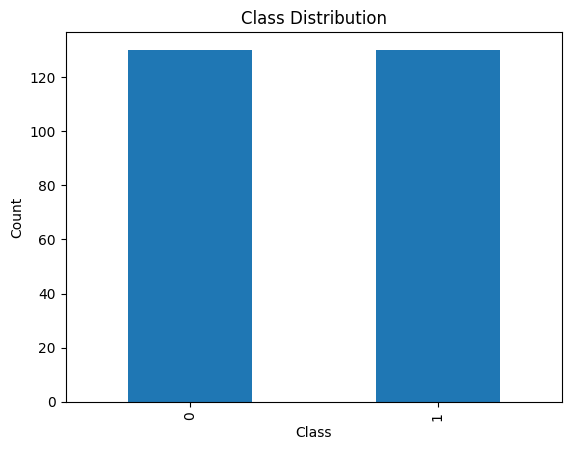

Dataset is balanced.
Class Distribution of:balancedData\pop_failure.csv
 target
0    494
1    494
Name: count, dtype: int64


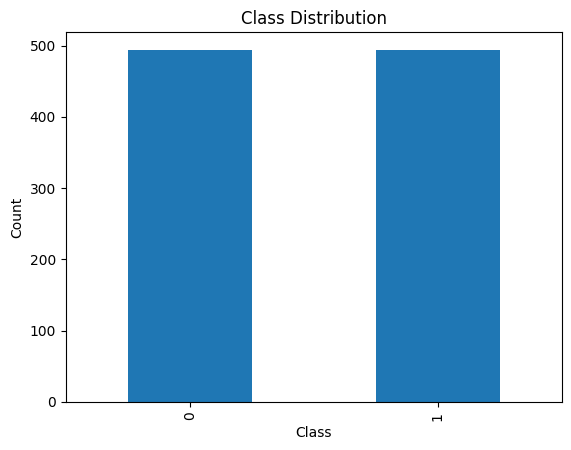

Dataset is balanced.
Class Distribution of:balancedData\postOpertaivePatient.csv
 target
0    63
3    63
1    63
2    63
Name: count, dtype: int64


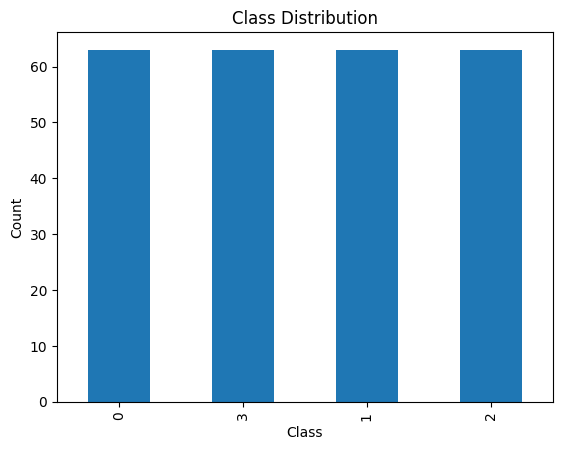

Dataset is balanced.
Class Distribution of:balancedData\Qualitative_Bankruptcy.csv
 Class
1    143
0    107
Name: count, dtype: int64


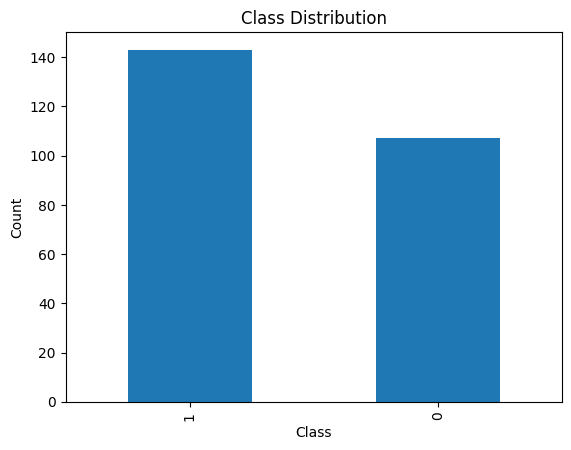

Dataset is balanced.
Class Distribution of:balancedData\Raisin_Dataset.csv
 Class
1    450
0    450
Name: count, dtype: int64


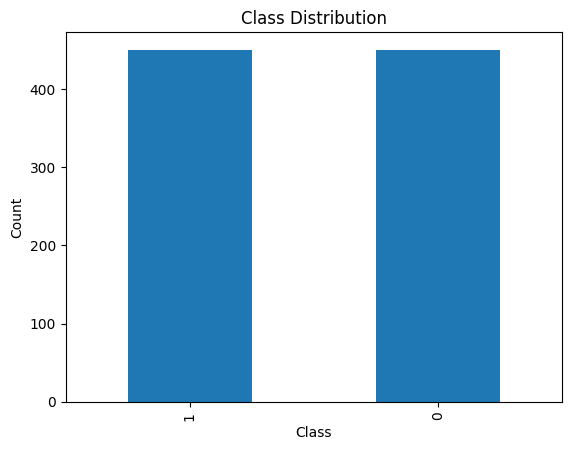

Dataset is balanced.
Class Distribution of:balancedData\risk_factors_cervical_cancer.csv
 target
0    803
1    803
Name: count, dtype: int64


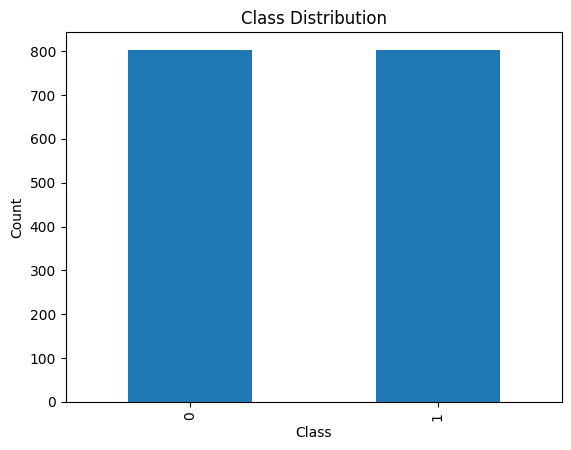

Dataset is balanced.
Class Distribution of:balancedData\seeds.csv
 class
0    70
1    70
2    70
Name: count, dtype: int64


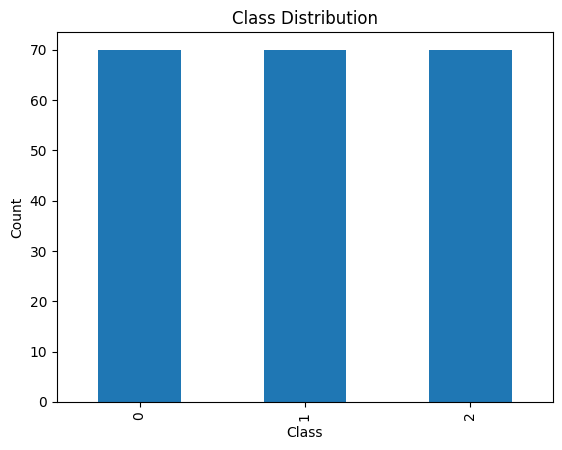

Dataset is balanced.
Class Distribution of:balancedData\shuttle.csv
 target
1    34108
3    34108
0    34108
4    34108
2    34108
6    34108
5    34108
Name: count, dtype: int64


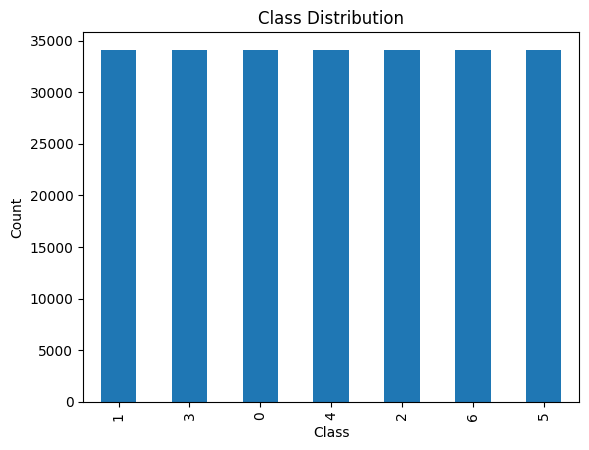

Dataset is balanced.
Class Distribution of:balancedData\sobar-72.csv
 target
1    51
0    51
Name: count, dtype: int64


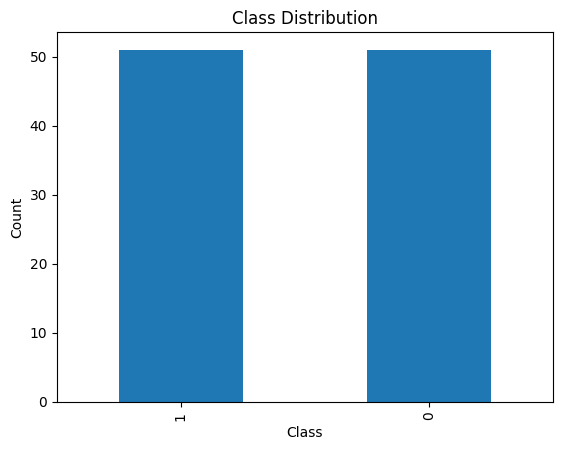

Dataset is balanced.
Class Distribution of:balancedData\somervilehappy.csv
 D
1    77
0    66
Name: count, dtype: int64


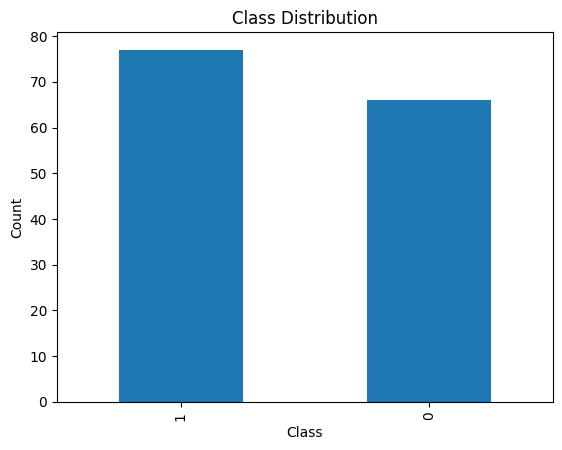

Dataset is balanced.
Class Distribution of:balancedData\soyabean-large.csv
 target
10    40
7     40
18    40
15    40
6     40
16    40
11    40
5     40
3     40
4     40
17    40
2     40
14    40
1     40
12    40
9     40
8     40
0     40
13    40
Name: count, dtype: int64


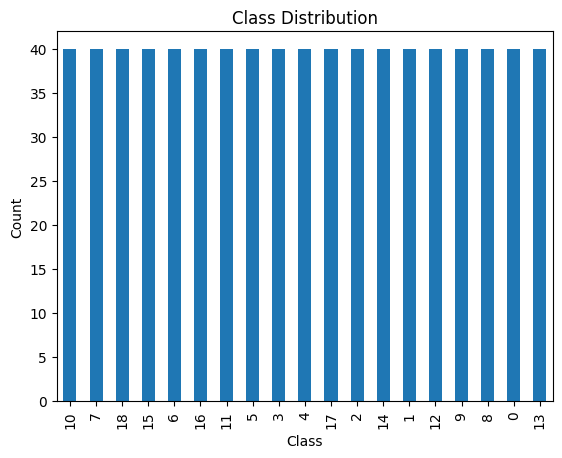

Dataset is balanced.
Class Distribution of:balancedData\Spam.csv
 spam
0    2788
1    1813
Name: count, dtype: int64


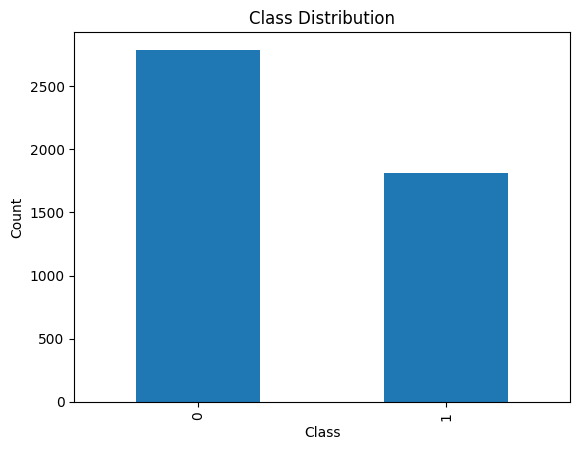

Dataset is balanced.
Class Distribution of:balancedData\spec-heart.csv
 class
1    40
0    40
Name: count, dtype: int64


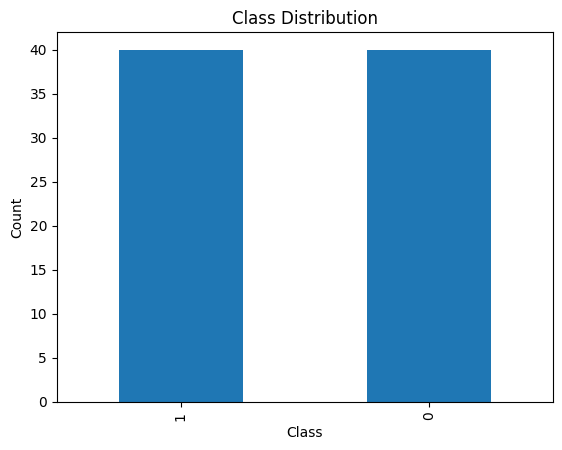

Dataset is balanced.
Class Distribution of:balancedData\sponge.csv
 target
2    70
1    70
0    70
Name: count, dtype: int64


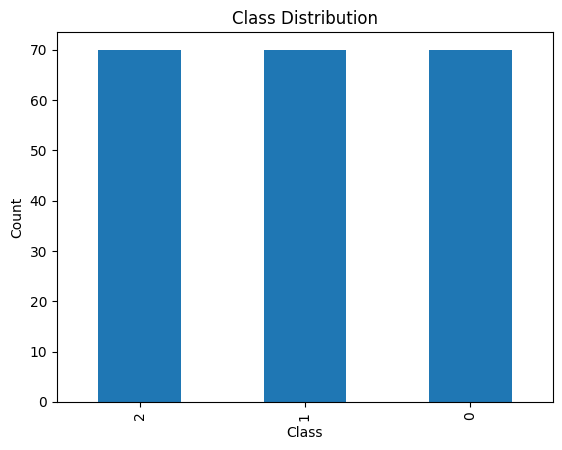

Dataset is balanced.
Class Distribution of:balancedData\statlog-austr.csv
 class
0    383
1    307
Name: count, dtype: int64


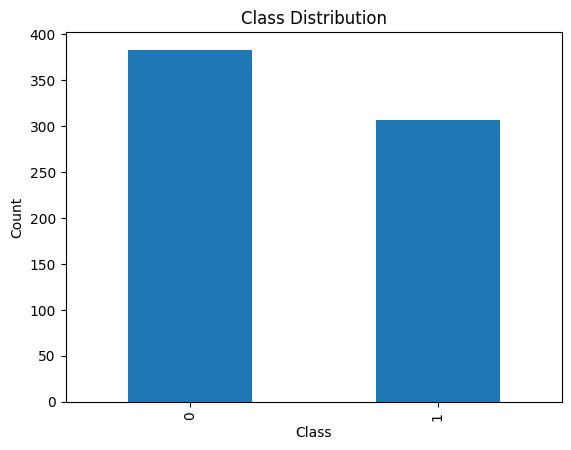

Dataset is balanced.
Class Distribution of:balancedData\statlog-german.csv
 target
0    700
1    700
Name: count, dtype: int64


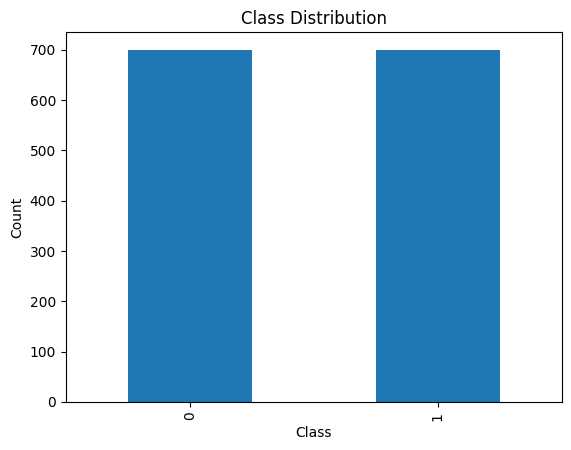

Dataset is balanced.
Class Distribution of:balancedData\statlog-heart.csv
 presence
0    150
1    120
Name: count, dtype: int64


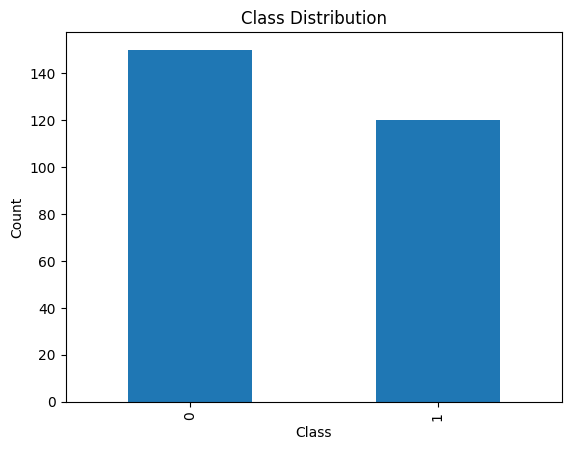

Dataset is balanced.
Class Distribution of:balancedData\statlog-heart2.csv
 class
0    150
1    120
Name: count, dtype: int64


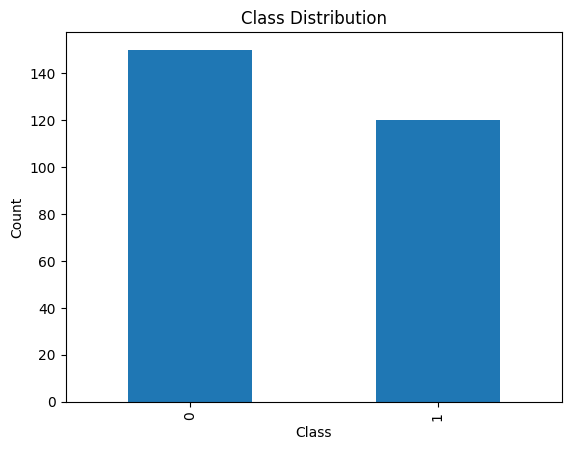

Dataset is balanced.
Class Distribution of:balancedData\statloglandsat.csv
 target
2    1072
3    1072
4    1072
5    1072
1    1072
0    1072
Name: count, dtype: int64


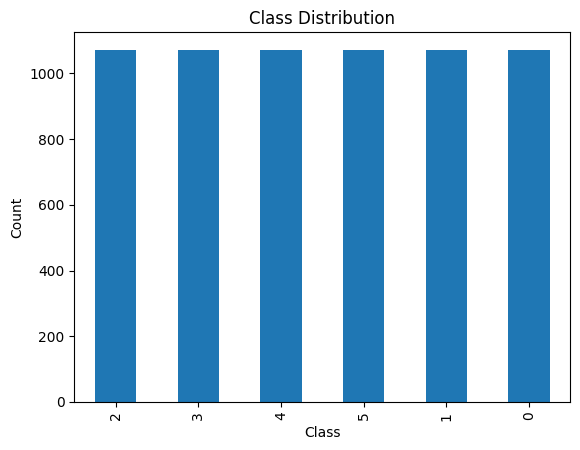

Dataset is balanced.
Class Distribution of:balancedData\studenperf.csv
 target
4     153
8     153
13    153
9     153
17    153
7     153
10    153
12    153
14    153
3     153
6     153
15    153
16    153
11    153
18    153
5     153
0     153
2     153
1     153
Name: count, dtype: int64


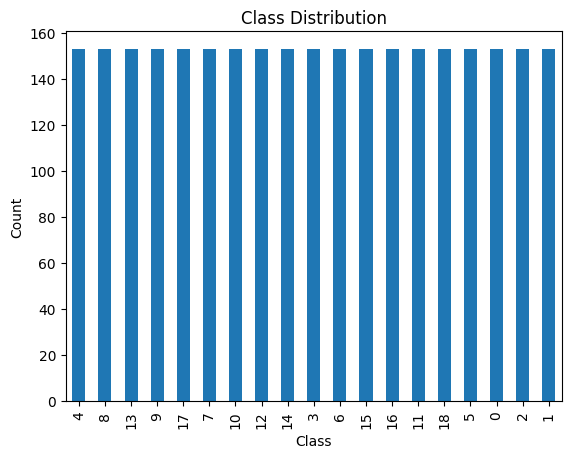

Dataset is balanced.
Class Distribution of:balancedData\student-dropout.csv
 target
0    2209
2    2209
1    2209
Name: count, dtype: int64


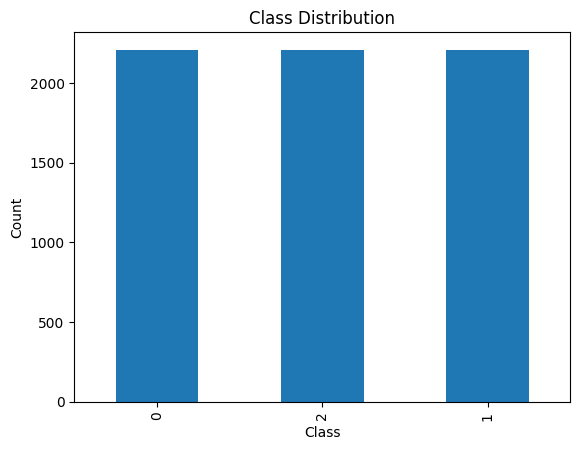

Dataset is balanced.
Class Distribution of:balancedData\teachingassper.csv
 class
2    52
1    50
0    49
Name: count, dtype: int64


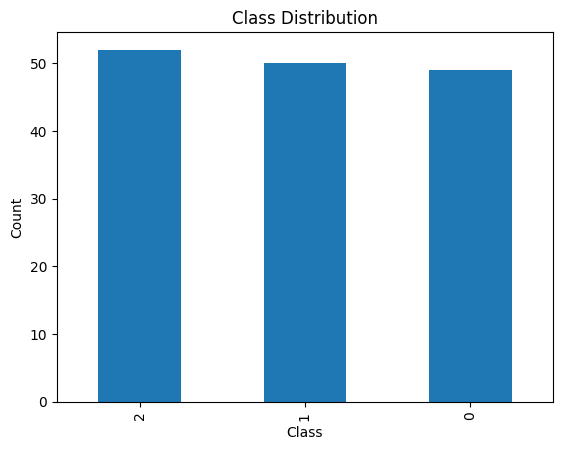

Dataset is balanced.
Class Distribution of:balancedData\thyroid.csv
 target
0    150
1    150
2    150
Name: count, dtype: int64


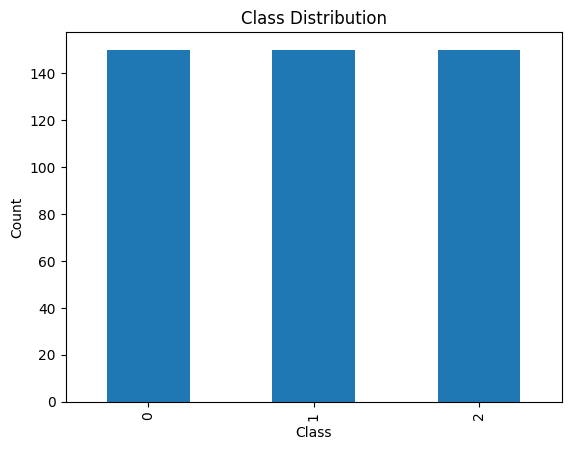

Dataset is balanced.
Class Distribution of:balancedData\Thyroid_Diff.csv
 target
0    275
1    275
Name: count, dtype: int64


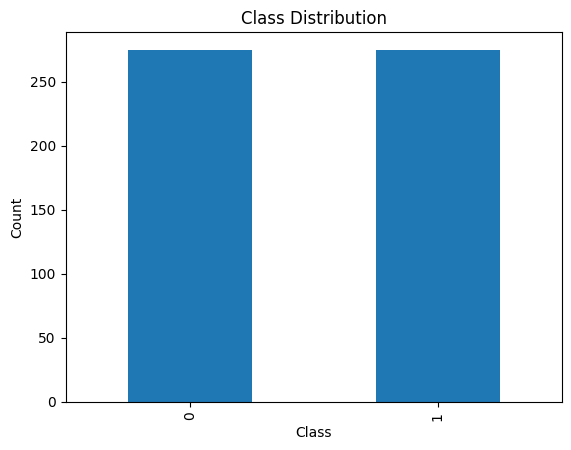

Dataset is balanced.
Class Distribution of:balancedData\tic-toe.csv
 class
1    626
0    332
Name: count, dtype: int64


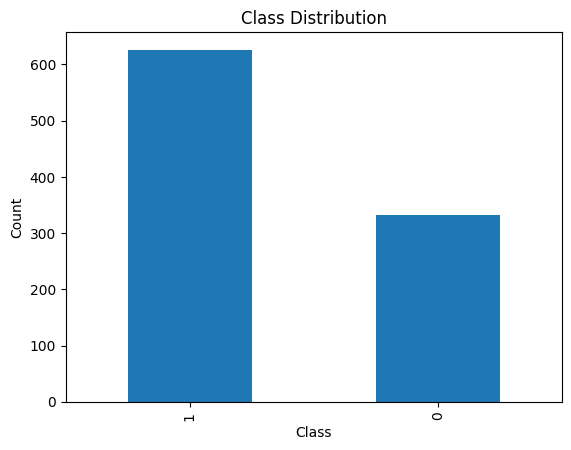

Dataset is balanced.
Class Distribution of:balancedData\transfusion.csv
 target
1    570
0    570
Name: count, dtype: int64


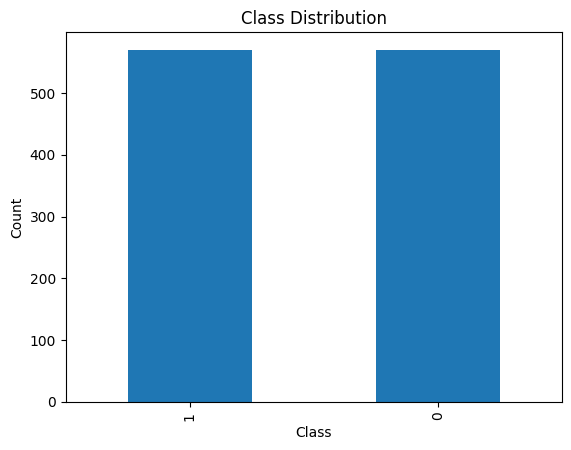

Dataset is balanced.
Class Distribution of:balancedData\turkiye-student-evaluation_R_Specific.csv
 target
0    3601
1    3601
2    3601
Name: count, dtype: int64


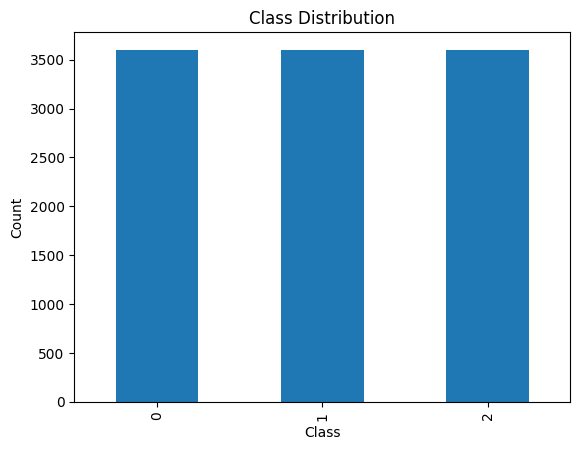

Dataset is balanced.
Class Distribution of:balancedData\vehicles.csv
 class
0    218
2    217
1    212
3    199
Name: count, dtype: int64


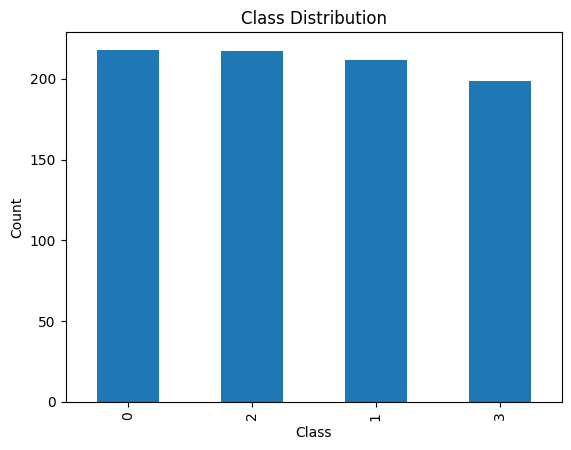

Dataset is balanced.
Class Distribution of:balancedData\waveform.csv
 class
2    1696
0    1657
1    1647
Name: count, dtype: int64


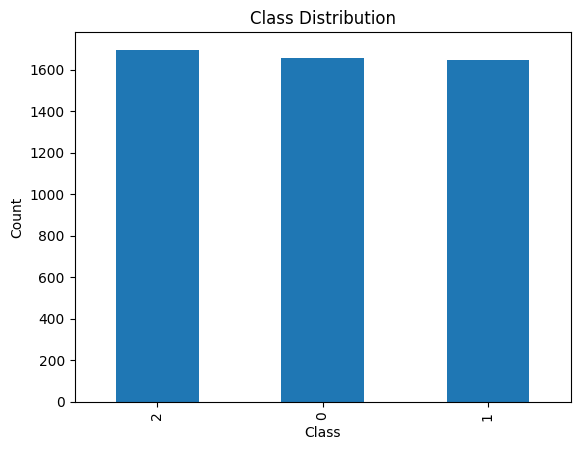

Dataset is balanced.
Class Distribution of:balancedData\waveformDG.csv
 class
0    1692
2    1655
1    1653
Name: count, dtype: int64


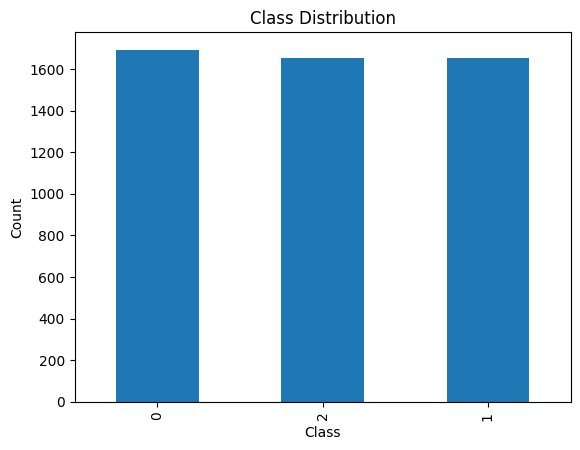

Dataset is balanced.
Class Distribution of:balancedData\Wholesale customers data.csv
 target
2    316
0    316
1    316
Name: count, dtype: int64


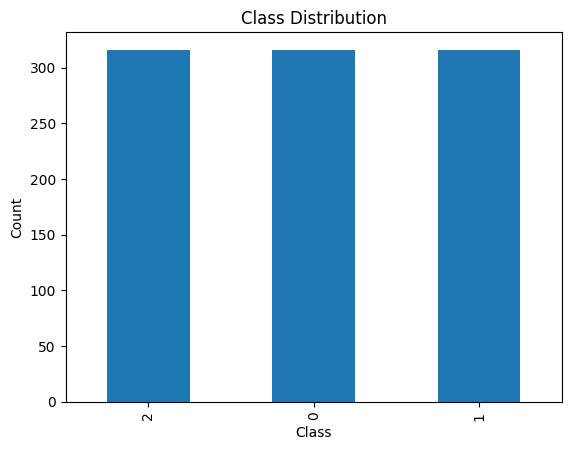

Dataset is balanced.
Class Distribution of:balancedData\wine.csv
 class
1    71
0    59
2    48
Name: count, dtype: int64


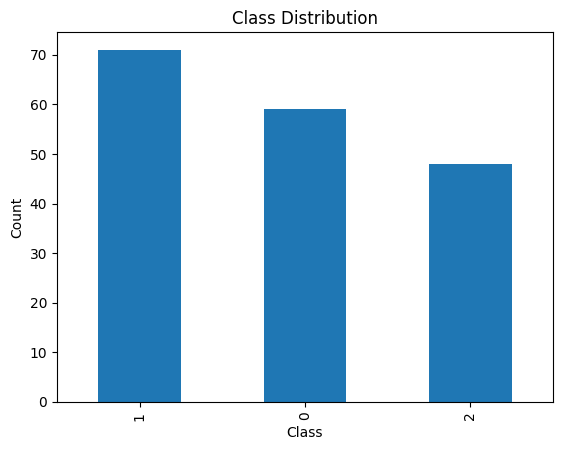

Dataset is balanced.
Class Distribution of:balancedData\wirelessloca.csv
 class
0    500
1    500
2    500
3    500
Name: count, dtype: int64


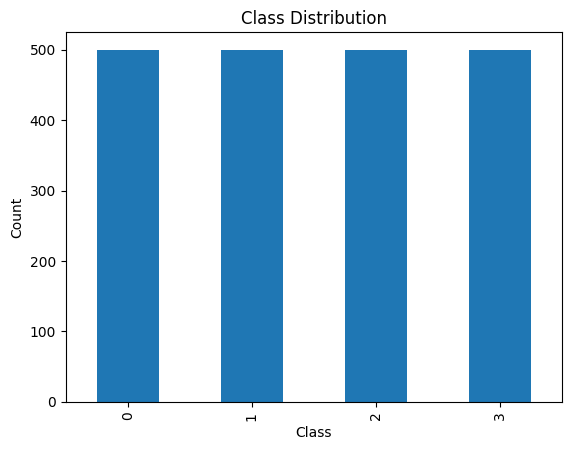

Dataset is balanced.
Class Distribution of:balancedData\yeast.csv
 target
6    463
7    463
0    463
3    463
2    463
4    463
5    463
9    463
8    463
1    463
Name: count, dtype: int64


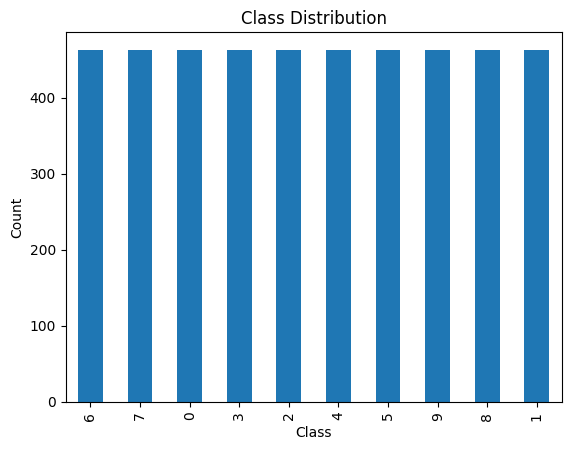

Dataset is balanced.
Class Distribution of:balancedData\zoo.csv
 target
0    41
3    41
1    41
6    41
5    41
4    41
2    41
Name: count, dtype: int64


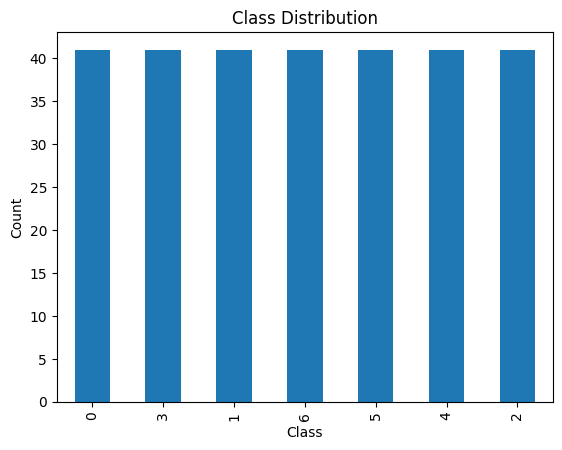

Dataset is balanced.
0


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import glob
imbalnceddata=[]
folder_path = "balancedData"
csv_files = glob.glob(folder_path + "/*.csv")  # Adjust for different file types

for i in range (len(csv_files)):
# Load dataset
    df = pd.read_csv(csv_files[i])  # Replace with your dataset

# Check class distribution
    class_counts = df.iloc[:,-1].value_counts()
    print("Class Distribution of:"+csv_files[i]+"\n", class_counts)

# Visualize class distribution
    class_counts.plot(kind='bar')
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.title("Class Distribution")
    plt.show()
    
    # Check imbalance
    imbalance_ratio = class_counts.min() / class_counts.max()
    if imbalance_ratio < 0.5:  # If the minority class is less than 50% of the majority
        print("Dataset is imbalanced.")
        apply_smote = True
        imbalnceddata.append(csv_files[i])
        
    else:
        print("Dataset is balanced.")
        apply_smote = False
print(len(imbalnceddata))